# Tarification automobile — Parties 2 et 3
## Analyse exploratoire et préparation des données (modèle de fréquence)

**Objectif du projet** : estimer la prime pure $\mathbb{E}[S] = \mathbb{P}(S>0) \times \mathbb{E}[S \mid S>0]$.

Ce notebook couvre :
- **Partie 1 (rappel)** : rôle de chaque fichier ;
- **Partie 2** : analyse exploratoire — cibles, variables explicatives, anomalies, fuites de données, lien avec la cible ;
- **Partie 3** : préparation — découpage train / validation, nettoyage, encodage, pipelines réutilisables.

> Périmètre : nous nous concentrons sur le **modèle de fréquence** (probabilité d'avoir au moins un sinistre). La cible de gravité est seulement décrite brièvement.

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.metrics import roc_auc_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

SEED = 42  # graine unique pour rendre tous les tirages aléatoires reproductibles
CIBLE = "nombre_sinistres"
MONTANT = "montant_sinistre"

---
# Partie 1 — Prise en main des données

| Fichier | Rôle |
|---|---|
| `train.csv` | Données d'entraînement : variables explicatives **et** cibles (`nombre_sinistres`, `montant_sinistre`) |
| `test.csv` | Données de test Kaggle : variables explicatives seulement, il faut prédire la prime |

`code_postal` est lu comme du texte pour ne pas perdre les zéros initiaux (ex. `01000`).

In [97]:
train = pd.read_csv("train.csv", dtype={"code_postal": str})
test = pd.read_csv("test.csv", dtype={"code_postal": str})

print("train :", train.shape)
print("test  :", test.shape)

colonnes_absentes_test = sorted(set(train.columns) - set(test.columns))
print("\nColonnes du train absentes du test :", colonnes_absentes_test)
print("Colonnes du test absentes du train :", sorted(set(test.columns) - set(train.columns)))
print("\nindex test : de", test["index"].min(), "à", test["index"].max())
train.head()

train : (50000, 33)
test  : (50000, 28)

Colonnes du train absentes du test : ['id_client', 'id_contrat', 'id_vehicule', 'montant_sinistre', 'nombre_sinistres']
Colonnes du test absentes du train : []

index test : de 50000 à 99999


,index,id_client,id_vehicule,id_contrat,bonus,type_contrat,duree_contrat,anciennete_info,freq_paiement,paiement,utilisation,code_postal,conducteur2,age_conducteur1,age_conducteur2,sex_conducteur1,sex_conducteur2,anciennete_permis1,anciennete_permis2,anciennete_vehicule,cylindre_vehicule,din_vehicule,essence_vehicule,marque_vehicule,modele_vehicule,debut_vente_vehicule,fin_vente_vehicule,vitesse_vehicule,type_vehicule,prix_vehicule,poids_vehicule,nombre_sinistres,montant_sinistre
0,0,A00000001,V01,A00000001-V01,0.5,Maxi,29,9,Biannual,No,Retired,36233,No,85,0,M,NaN,62,0,10.0,1587,98,Gasoline,PEUGEOT,306,10,9,182,Tourism,20700,1210,0,0.0
1,1,A00000002,V01,A00000002-V01,0.5,Maxi,3,1,Biannual,No,Retired,92073,No,69,0,M,NaN,39,0,4.0,2149,170,Diesel,MERCEDES BENZ,C220,4,2,229,Tourism,34250,1510,0,0.0
2,2,A00000003,V01,A00000003-V01,0.5,Maxi,2,2,Yearly,No,WorkPrivate,92026,No,37,0,M,NaN,18,0,11.0,1991,150,Gasoline,BMW,Z3,12,11,210,Tourism,28661,1270,0,0.0
3,3,A00000004,V01,A00000004-V01,0.5,Median2,22,1,Yearly,No,WorkPrivate,78537,Yes,81,21,M,F,54,3,16.0,1781,90,Gasoline,VOLKSWAGEN,GOLF,18,15,180,Tourism,14407,1020,0,0.0
4,4,A00000005,V01,A00000005-V01,0.5,Maxi,16,4,Biannual,No,Retired,38544,Yes,62,68,F,M,37,48,11.0,1598,108,Gasoline,RENAULT,LAGUNA,13,11,195,Tourism,16770,1230,0,0.0


**Constat** : le test contient toutes les variables du train **sauf** les deux cibles et les trois identifiants (`id_client`, `id_vehicule`, `id_contrat`).
Toute variable présente dans le test est donc connue au moment de la tarification ; c'est un premier indice pour la question des fuites (§2.4).

---
# Partie 2 — Analyse exploratoire

## 2.1 Cible de fréquence : `nombre_sinistres`

,Effectif,Pourcentage (%)
nombre_sinistres,,
0,47083,94.17
1,2917,5.83


Taux de sinistralité moyen : 5.83%


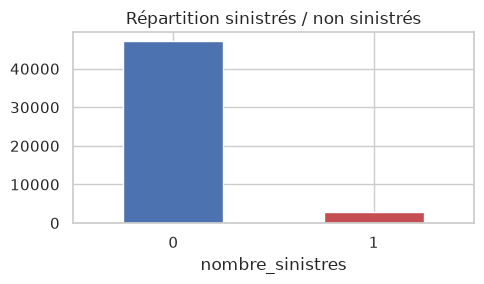

In [98]:
repartition = pd.DataFrame({
    "Effectif": train[CIBLE].value_counts(),
    "Pourcentage (%)": train[CIBLE].value_counts(normalize=True).mul(100).round(2),
}).sort_index()
display(repartition)

taux_moyen = train[CIBLE].mean()
print(f"Taux de sinistralité moyen : {taux_moyen:.2%}")

ax = repartition["Effectif"].plot.bar(figsize=(5, 3), color=["#4C72B0", "#C44E52"], rot=0)
ax.set_title("Répartition sinistrés / non sinistrés")
ax.set_xlabel("nombre_sinistres")
plt.tight_layout()
plt.show()

**Constats**
- `nombre_sinistres` ne prend que les valeurs 0 et 1 : la cible est directement **binaire**.
- Les classes sont **très déséquilibrées** : environ 94 % de non-sinistrés pour 6 % de sinistrés.

**Conséquence**
- Pour le découpage, il faudra **stratifier** sur la cible afin de garder environ 6 % de sinistrés dans chaque jeu.

> Les conséquences de ce déséquilibre sur le choix de la métrique sont traitées en **partie 4**, avec la modélisation.

## 2.3 Description des variables explicatives

On regroupe les colonnes par thème métier pour structurer l'analyse.

In [99]:
IDENTIFIANTS = ["index", "id_client", "id_vehicule", "id_contrat"]
CIBLES = [CIBLE, MONTANT]

VAR_CONTRAT = ["bonus", "type_contrat", "duree_contrat", "anciennete_info",
               "freq_paiement", "paiement", "utilisation"]
VAR_CONDUCTEURS = ["conducteur2", "age_conducteur1", "age_conducteur2",
                   "sex_conducteur1", "sex_conducteur2",
                   "anciennete_permis1", "anciennete_permis2"]
VAR_VEHICULE = ["anciennete_vehicule", "cylindre_vehicule", "din_vehicule",
                "essence_vehicule", "marque_vehicule", "modele_vehicule",
                "debut_vente_vehicule", "fin_vente_vehicule", "vitesse_vehicule",
                "type_vehicule", "prix_vehicule", "poids_vehicule"]
VAR_GEO = ["code_postal"]

explicatives = VAR_CONTRAT + VAR_CONDUCTEURS + VAR_VEHICULE + VAR_GEO
assert set(explicatives + IDENTIFIANTS + CIBLES) == set(train.columns)

numeriques = [c for c in explicatives if pd.api.types.is_numeric_dtype(train[c])]
categorielles = [c for c in explicatives if c not in numeriques]
print("Numériques   :", numeriques)
print("Catégorielles:", categorielles)

Numériques   : ['bonus', 'duree_contrat', 'anciennete_info', 'age_conducteur1', 'age_conducteur2', 'anciennete_permis1', 'anciennete_permis2', 'anciennete_vehicule', 'cylindre_vehicule', 'din_vehicule', 'debut_vente_vehicule', 'fin_vente_vehicule', 'vitesse_vehicule', 'prix_vehicule', 'poids_vehicule']
Catégorielles: ['type_contrat', 'freq_paiement', 'paiement', 'utilisation', 'conducteur2', 'sex_conducteur1', 'sex_conducteur2', 'essence_vehicule', 'marque_vehicule', 'modele_vehicule', 'type_vehicule', 'code_postal']


In [100]:
# Tableau de synthèse : type, manquants, cardinalité, statistiques descriptives
resume = pd.DataFrame(index=explicatives)
resume["Thème"] = (["Contrat"] * len(VAR_CONTRAT) + ["Conducteurs"] * len(VAR_CONDUCTEURS)
                   + ["Véhicule"] * len(VAR_VEHICULE) + ["Géographie"])
resume["Type"] = ["numérique" if c in numeriques else "catégorielle" for c in explicatives]
resume["Manquants"] = train[explicatives].isna().sum()
resume["Manquants (%)"] = (train[explicatives].isna().mean() * 100).round(2)
resume["Modalités"] = train[explicatives].nunique()

stats = train[numeriques].describe(percentiles=[0.01, 0.5, 0.99]).T
stats = stats[["mean", "std", "min", "1%", "50%", "99%", "max"]]
stats.columns = ["Moyenne", "Écart-type", "Min", "P1", "Médiane", "P99", "Max"]
resume.join(stats.round(2))

,Thème,Type,Manquants,Manquants (%),Modalités,Moyenne,Écart-type,Min,P1,Médiane,P99,Max
bonus,Contrat,numérique,0,0.00,73,0.54,0.10,0.5,0.5,0.5,0.95,2.16
type_contrat,Contrat,catégorielle,0,0.00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duree_contrat,Contrat,numérique,0,0.00,41,11.09,8.57,1.0,1.0,9.0,31.00,41.00
anciennete_info,Contrat,numérique,0,0.00,25,2.73,2.35,1.0,1.0,2.0,12.00,25.00
freq_paiement,Contrat,catégorielle,0,0.00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paiement,Contrat,catégorielle,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utilisation,Contrat,catégorielle,0,0.00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
conducteur2,Conducteurs,catégorielle,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_conducteur1,Conducteurs,numérique,0,0.00,83,54.65,14.87,19.0,24.0,54.0,86.00,101.00
age_conducteur2,Conducteurs,numérique,0,0.00,81,15.57,23.99,0.0,0.0,0.0,78.00,99.00


### Variables catégorielles : modalités et modalités rares
Une modalité trop rare (ici, moins de 50 lignes) ne permet pas d'estimer un effet fiable : le modèle risque d'apprendre du bruit (sur-apprentissage).

In [101]:
SEUIL_RARE = 50

lignes = []
for c in categorielles:
    vc = train[c].value_counts()
    lignes.append({
        "variable": c,
        "modalités": vc.size,
        "modalités rares (< %d lignes)" % SEUIL_RARE: (vc < SEUIL_RARE).sum(),
        "lignes concernées": vc[vc < SEUIL_RARE].sum(),
        "modalité la plus fréquente": f"{vc.index[0]} ({vc.iloc[0] / len(train):.0%})",
    })
display(pd.DataFrame(lignes).set_index("variable"))

for c in ["type_contrat", "freq_paiement", "paiement", "utilisation",
          "essence_vehicule", "type_vehicule", "conducteur2", "sex_conducteur1"]:
    print(c, train[c].value_counts(dropna=False).to_dict())

,modalités,modalités rares (< 50 lignes),lignes concernées,modalité la plus fréquente
variable,,,,
type_contrat,4,0,0,Maxi (65%)
freq_paiement,4,0,0,Yearly (38%)
paiement,2,0,0,No (96%)
utilisation,4,1,48,WorkPrivate (66%)
conducteur2,2,0,0,No (67%)
sex_conducteur1,2,0,0,M (60%)
sex_conducteur2,2,0,0,F (20%)
essence_vehicule,3,1,46,Diesel (55%)
marque_vehicule,89,54,527,RENAULT (27%)


type_contrat {'Maxi': 32360, 'Median2': 8759, 'Median1': 4638, 'Mini': 4243}
freq_paiement {'Yearly': 18948, 'Monthly': 15045, 'Biannual': 14769, 'Quarterly': 1238}
paiement {'No': 47927, 'Yes': 2073}
utilisation {'WorkPrivate': 32941, 'Retired': 13344, 'Professional': 3667, 'AllTrips': 48}
essence_vehicule {'Diesel': 27476, 'Gasoline': 22478, 'Hybrid': 46}
type_vehicule {'Tourism': 45036, 'Commercial': 4964}
conducteur2 {'No': 33406, 'Yes': 16594}
sex_conducteur1 {'M': 30097, 'F': 19903}


**Constats**
- F**aible cardinalité (≤ 4 modalités)** : `type_contrat`, `freq_paiement`, `paiement`, `utilisation`, `essence_vehicule`, `type_vehicule`, `conducteur2`, `sex_*`. Quelques modalités rares : `utilisation = AllTrips` (48 lignes), `essence_vehicule = Hybrid` (46 lignes).
- **Forte cardinalité** :
  - `marque_vehicule` : 89 modalités, dont la majorité sont rares ;
  - `modele_vehicule` : 886 modalités, dont plus de 80 % sont rares ;
  - `code_postal` : environ 12 800 modalités, inutilisable tel quel.

  Ces variables demanderont un traitement spécifique : regroupement des rares, encodage par la cible, ou réduction au **département** pour le code postal.
- `sex_conducteur2` a environ 67 % de « manquants » : on vérifie plus bas qu'ils correspondent exactement aux contrats sans second conducteur (manquant **structurel**).

In [102]:
# Code postal -> département (2 premiers chiffres)
dept = train["code_postal"].str[:2]
print("Nombre de départements :", dept.nunique())
print("Départements du test absents du train :",
      set(test["code_postal"].str[:2]) - set(dept))
print("Modèles de véhicule du test absents du train :",
      len(set(test["modele_vehicule"]) - set(train["modele_vehicule"])))
print("Marques du test absentes du train :",
      len(set(test["marque_vehicule"]) - set(train["marque_vehicule"])))

Nombre de départements : 96
Départements du test absents du train : set()
Modèles de véhicule du test absents du train : 137
Marques du test absentes du train : 12


→ Des modèles (et éventuellement des marques) du test n'existent pas dans le train : le pipeline devra **gérer les modalités inconnues** sans planter.

on pourrait créer une valeur taux ?? 

### Variables numériques : valeurs aberrantes et incohérences

In [103]:
def compter(masque_train, masque_test, description, traitement):
    return {"anomalie": description, "train": int(masque_train.sum()),
            "test": int(masque_test.sum()), "traitement prévu (partie 3)": traitement}

anomalies = pd.DataFrame([
    compter(train["poids_vehicule"] == 0, test["poids_vehicule"] == 0,
            "poids_vehicule = 0", "valeur impossible → NaN puis imputation"),
    compter(train["cylindre_vehicule"] == 0, test["cylindre_vehicule"] == 0,
            "cylindre_vehicule = 0", "valeur impossible → NaN puis imputation"),
    compter(train["anciennete_vehicule"].isna(), test["anciennete_vehicule"].isna(),
            "anciennete_vehicule manquante", "imputation par la médiane"),
    compter(train["fin_vente_vehicule"] > train["debut_vente_vehicule"],
            test["fin_vente_vehicule"] > test["debut_vente_vehicule"],
            "fin de vente plus ancienne que début de vente", "rien (aucun cas)"),
]).set_index("anomalie")
anomalies


,train,test,traitement prévu (partie 3)
anomalie,,,
poids_vehicule = 0,1883,1861,valeur impossible → NaN puis imputation
cylindre_vehicule = 0,3,2,valeur impossible → NaN puis imputation
anciennete_vehicule manquante,1,0,imputation par la médiane
fin de vente plus ancienne que début de vente,0,0,rien (aucun cas)


In [104]:
# Second conducteur : les zéros et les NaN sont-ils structurels ?
sans_c2 = train["conducteur2"] == "No"
print("Sans 2e conducteur :", sans_c2.sum())
print("  dont age_conducteur2 = 0        :", (train.loc[sans_c2, "age_conducteur2"] == 0).sum())
print("  dont anciennete_permis2 = 0     :", (train.loc[sans_c2, "anciennete_permis2"] == 0).sum())
print("  dont sex_conducteur2 manquant   :", train.loc[sans_c2, "sex_conducteur2"].isna().sum())
print("Avec 2e conducteur et age_conducteur2 = 0 :",
      ((~sans_c2) & (train["age_conducteur2"] == 0)).sum())

Sans 2e conducteur : 33406
  dont age_conducteur2 = 0        : 33406
  dont anciennete_permis2 = 0     : 33406
  dont sex_conducteur2 manquant   : 33406
Avec 2e conducteur et age_conducteur2 = 0 : 0


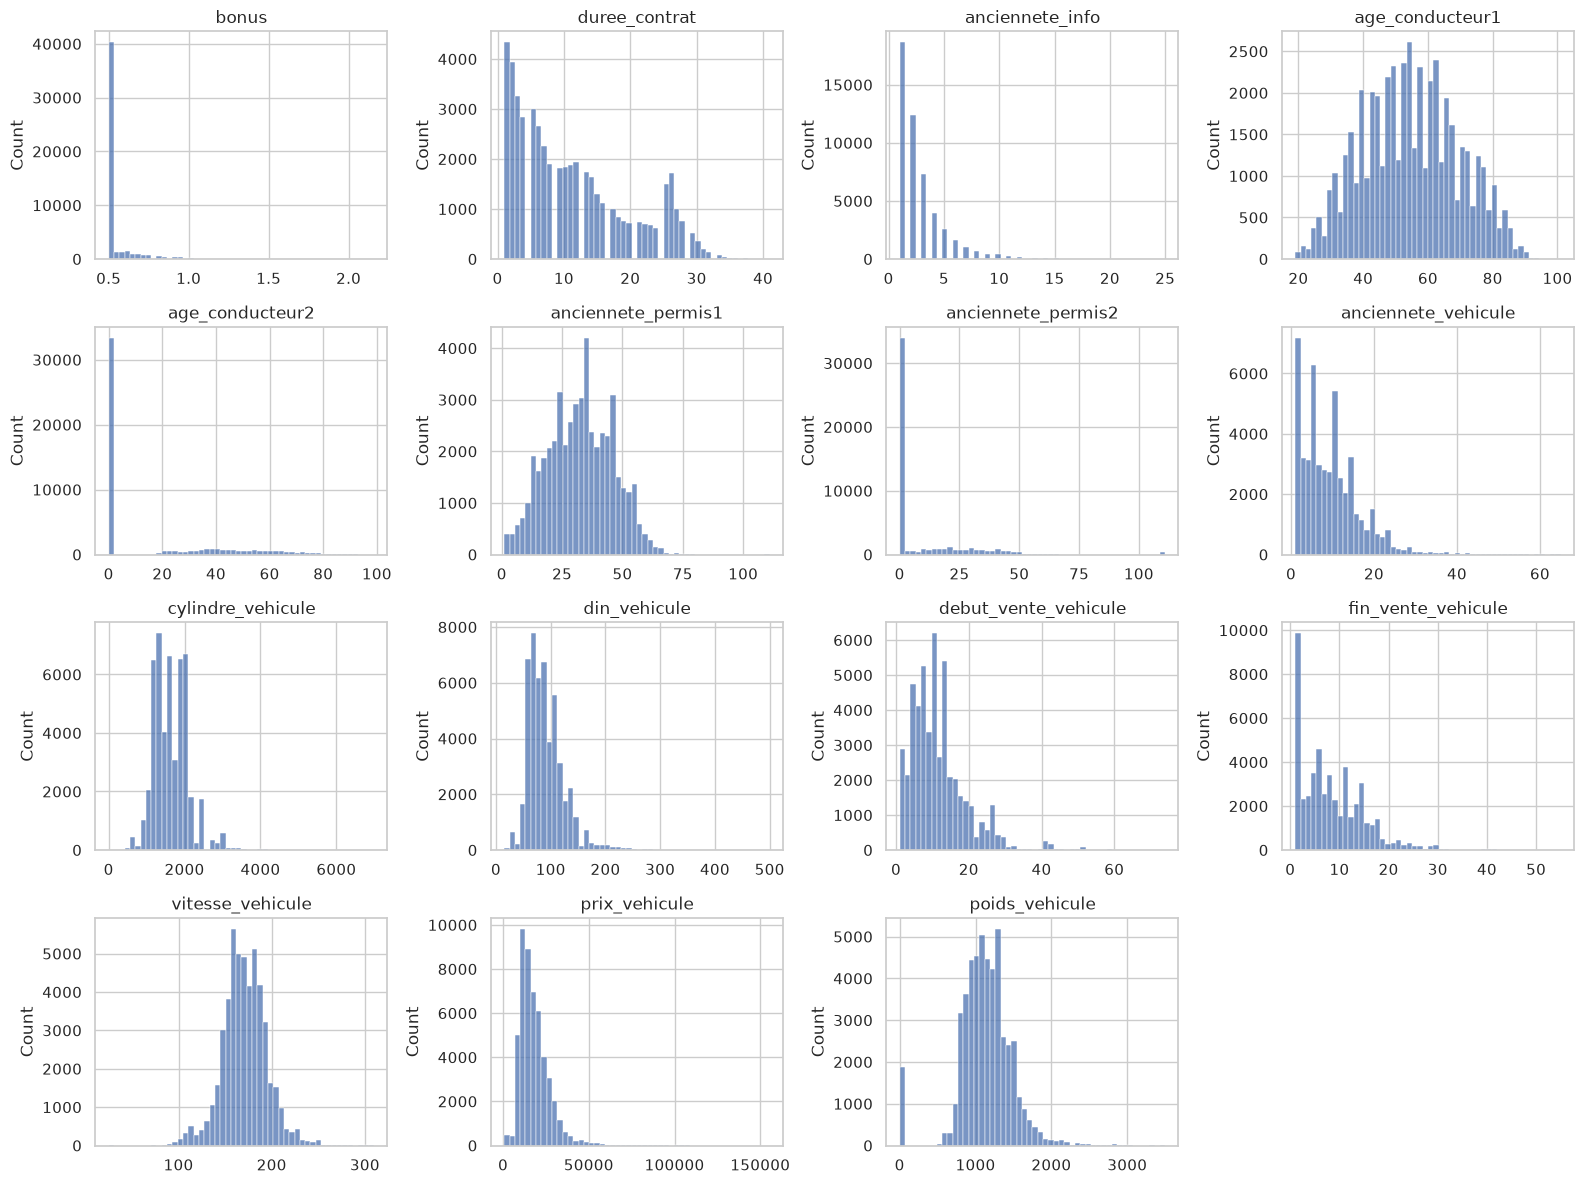

In [105]:
# Distributions des variables numériques (repérer queues lourdes et pics)
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, c in zip(axes.ravel(), numeriques):
    sns.histplot(train[c], bins=50, ax=ax)
    ax.set_title(c)
    ax.set_xlabel("")
for ax in axes.ravel()[len(numeriques):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Constats**
- `poids_vehicule = 0` concerne environ 1 900 lignes (aussi présentes dans le test) : ce n'est pas un vrai poids mais une **valeur manquante déguisée**. Même chose pour les 3 `cylindre_vehicule = 0`.
- Pour les contrats **sans second conducteur**, `age_conducteur2 = 0`, `anciennete_permis2 = 0` et `sex_conducteur2 = NaN` dans 100 % des cas. Ce ne sont pas des erreurs mais des **valeurs structurelles** : l'information est portée par `conducteur2`.
- Plusieurs variables ont une **queue lourde à droite** (`prix_vehicule` jusqu'à environ 155 000 €, `din_vehicule` jusqu'à 500 ch, `anciennete_vehicule`) : un passage au log aidera les modèles linéaires.
- `bonus` est concentré à 0,50 (bonus maximal), avec une longue traîne de malus jusqu'à 2,16.

## 2.4 Fuites de données

**Critère** : une variable est utilisable seulement si sa valeur est **connue au moment de la signature du contrat**, c'est-à-dire avant la période de couverture sur laquelle on compte les sinistres.

| Variable(s) | Connue à la tarification ? | Décision |
|---|---|---|
| `nombre_sinistres` | Non — c'est la cible | Cible |
| `montant_sinistre` | Non — observé après le sinistre, et `> 0` si et seulement si `nombre_sinistres = 1` | **Exclue** (fuite directe) |
| `id_client`, `id_vehicule`, `id_contrat`, `index` | Oui, mais sans signification métier et absents du test | **Exclues** des variables (`id_client` gardé pour le découpage) |
| `bonus` | Oui : le coefficient bonus-malus est calculé **à partir des sinistres passés**, fixé au début de la période | Conservée |
| `type_contrat`, `duree_contrat`, `anciennete_info`, `freq_paiement`, `paiement`, `utilisation` | Oui : caractéristiques du contrat choisies à la souscription | Conservées |
| Conducteurs, véhicule, code postal | Oui : déclarés à la souscription | Conservées (sauf sexe, voir 3.1) |

Ces variables de contrat sont d'ailleurs **toutes présentes dans `test.csv`**, ce qui confirme qu'elles sont disponibles au moment de prédire.

> Nuance : on suppose que `bonus` est la valeur au **début** de la période. S'il était mis à jour après les sinistres de la période, il contiendrait une fuite. Ici, sa faible relation avec la cible (§2.5) et sa présence dans le test rendent cette hypothèse raisonnable.

## 2.5 Lien entre les variables explicatives et la cible de fréquence

### Pourquoi ne pas se contenter d'une matrice de corrélation ?
La proportion de non-sinistrés étant de 94 % contre 6 %, les coefficients de corrélation sont mécaniquement très petits, **même quand le lien est fort** : par exemple, pour `anciennete_vehicule`, r ≈ −0,10 alors que le taux de sinistres passe de 8,4 % à 2 % entre les véhicules récents et anciens.
De plus, la corrélation ne mesure que les liens **linéaires** et ne s'applique pas aux variables **catégorielles**.


### Méthode retenue : le taux de sinistralité par classe
Pour chaque variable, on calcule le **taux de sinistres** dans chaque modalité (variables catégorielles) ou dans chaque **quintile** (variables numériques). On le compare au taux moyen du portefeuille (ligne rouge).
C'est l'outil de référence en tarification : il est lisible, il capte les effets non linéaires, et il s'interprète directement en écart de risque.

In [106]:
def taux_par_classe(df, col, cible=CIBLE, n_bins=5):
    # Taux de sinistres et effectif par modalité (ou par quantile pour une variable continue)
    x = df[col]
    if pd.api.types.is_numeric_dtype(x) and x.nunique() > 10:
        x = pd.qcut(x, n_bins, duplicates="drop")
    return df.groupby(x, observed=True)[cible].agg(taux="mean", effectif="size")


def tracer_taux(df, colonnes, n_cols=3, cible=CIBLE):
    n_rows = int(np.ceil(len(colonnes) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.6 * n_rows))
    taux_global = df[cible].mean()
    for ax, col in zip(np.ravel(axes), colonnes):
        g = taux_par_classe(df, col, cible)
        # intervalle de confiance à 95 % d'une proportion : 1.96 * sqrt(p(1-p)/n)
        erreur = 1.96 * np.sqrt(g["taux"] * (1 - g["taux"]) / g["effectif"])
        ax.bar(range(len(g)), g["taux"], yerr=erreur, capsize=3, color="#4C72B0")
        ax.axhline(taux_global, color="red", ls="--", lw=1)
        ax.set_xticks(range(len(g)))
        ax.set_xticklabels([str(i) for i in g.index], rotation=35, ha="right", fontsize=8)
        ax.set_title(col)
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1, decimals=0))
    for ax in np.ravel(axes)[len(colonnes):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

### Variables liées au contrat

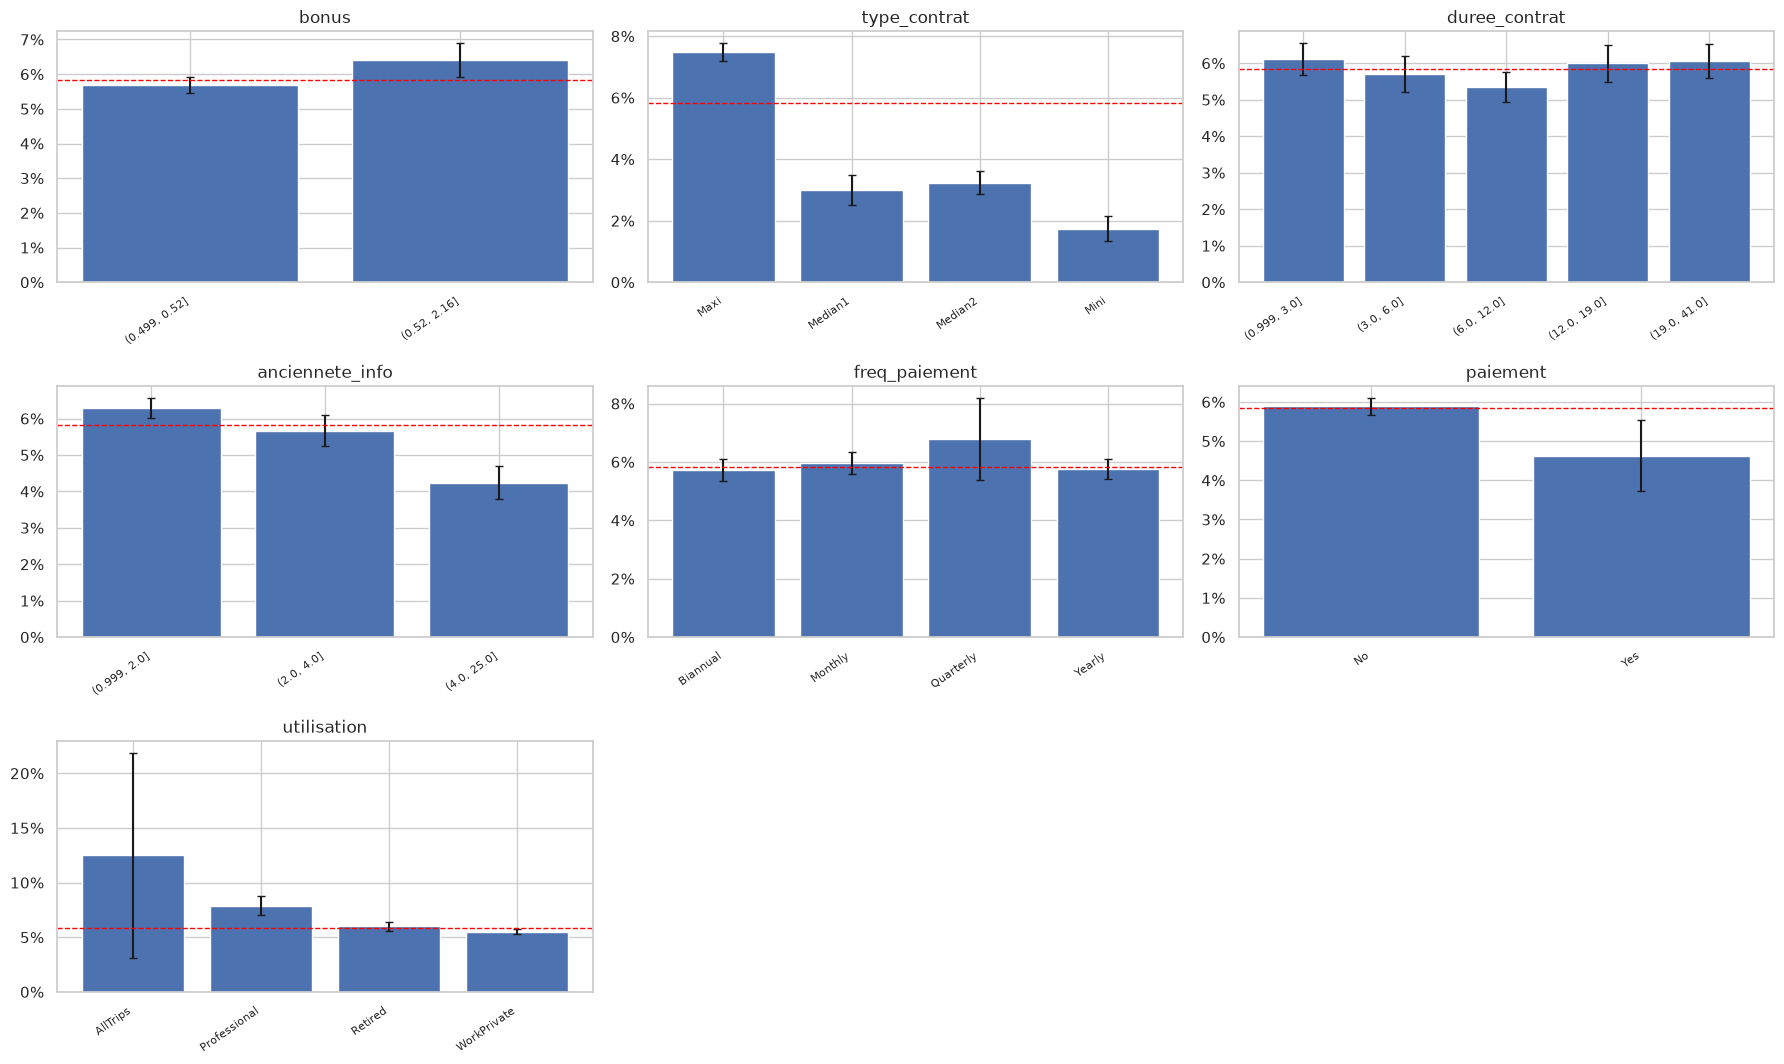

In [107]:
tracer_taux(train, VAR_CONTRAT)

### Variables liées aux conducteurs

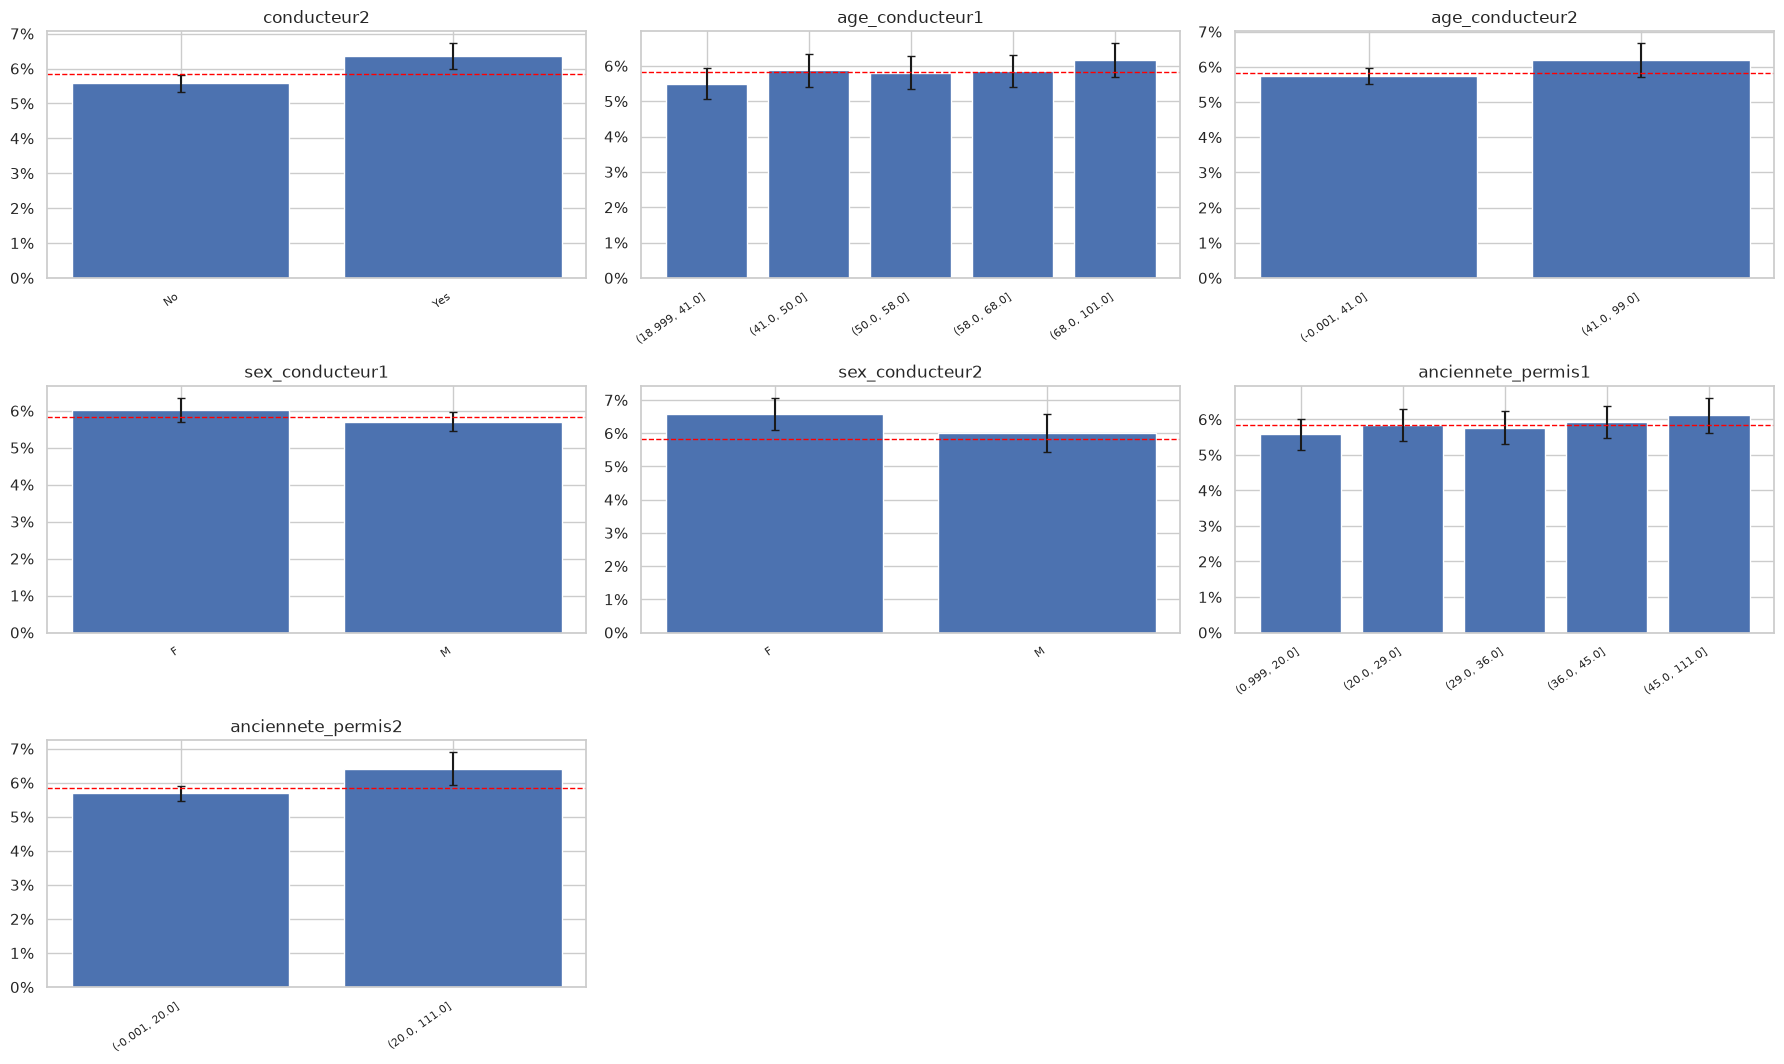

In [108]:
tracer_taux(train, VAR_CONDUCTEURS)

### Variables liées au véhicule

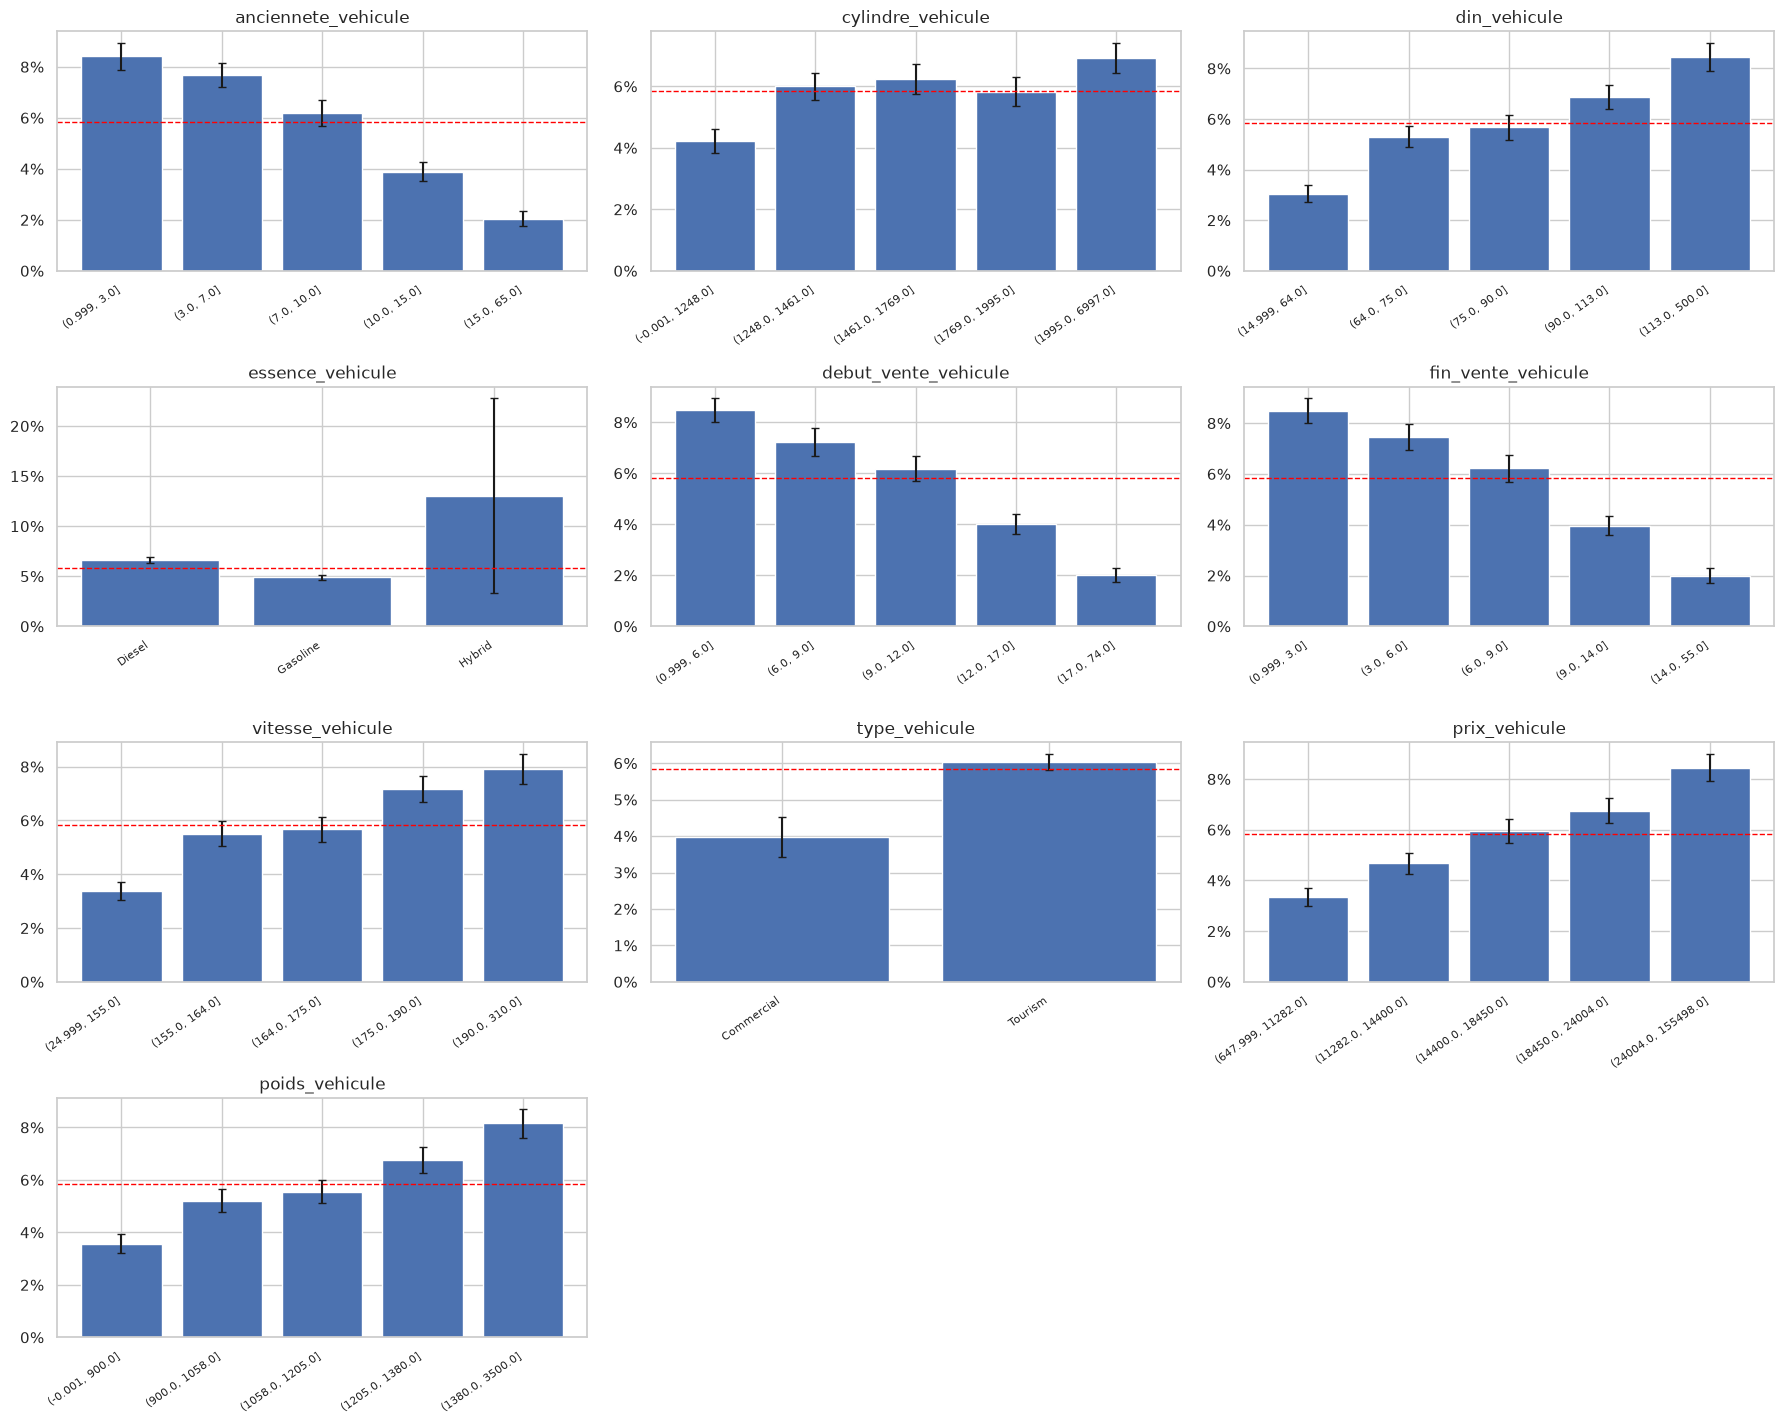

In [109]:
vehicule_peu_modalites = [c for c in VAR_VEHICULE if c not in ("marque_vehicule", "modele_vehicule")]
tracer_taux(train, vehicule_peu_modalites)

### Variables à forte cardinalité : marque et département
On n'affiche que les modalités ayant suffisamment d'observations (au moins 500 lignes), sinon les taux sont trop bruités.

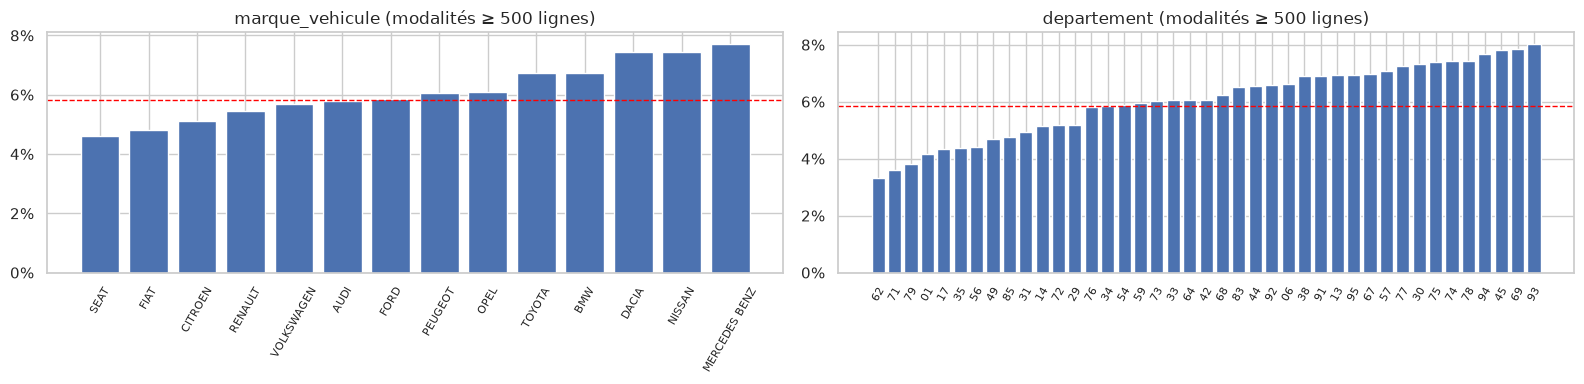

In [110]:
tmp = train.assign(departement=train["code_postal"].str[:2])

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, col in zip(axes, ["marque_vehicule", "departement"]):
    g = taux_par_classe(tmp, col)
    g = g[g["effectif"] >= 500].sort_values("taux")
    ax.bar(g.index.astype(str), g["taux"], color="#4C72B0")
    ax.axhline(taux_moyen, color="red", ls="--", lw=1)
    ax.set_title(f"{col} (modalités ≥ 500 lignes)")
    ax.tick_params(axis="x", rotation=60, labelsize=8)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1, decimals=0))
plt.tight_layout()
plt.show()

### Classement des variables les plus discriminantes
Pour résumer les graphiques, on calcule pour chaque variable numérique sa **corrélation** avec `nombre_sinistres`.

Points de lecture :
- les valeurs sont **petites** à cause du déséquilibre des classes (94 % / 6 %) : on s'intéresse donc au **classement** des variables plutôt qu'à la valeur du coefficient ;
- on classe selon la **valeur absolue** |r| : le signe indique seulement le sens du lien (r > 0 : plus la variable est grande, plus le taux de sinistres est élevé) ;
- la corrélation ne s'applique pas aux variables **catégorielles** : pour elles, on s'appuie sur les graphiques de taux par classe ci-dessus.


In [111]:
classement = train[numeriques].corrwith(train[CIBLE]).to_frame("corrélation")
classement["|corrélation|"] = classement["corrélation"].abs()
classement = classement.sort_values("|corrélation|", ascending=False).round(3)
classement


,corrélation,|corrélation|
anciennete_vehicule,-0.097,0.097
fin_vente_vehicule,-0.097,0.097
debut_vente_vehicule,-0.097,0.097
din_vehicule,0.074,0.074
prix_vehicule,0.074,0.074
vitesse_vehicule,0.070,0.070
poids_vehicule,0.058,0.058
cylindre_vehicule,0.032,0.032
anciennete_info,-0.032,0.032
anciennete_permis2,0.018,0.018


### Synthèse du lien avec la fréquence

| Effet | Variables | Corrélation | Observation (graphiques de taux) |
|---|---|---|---|
| **Très fort** | `type_contrat` | — (catégorielle) | De 1,7 % (Mini) à 7,5 % (Maxi). Hypothèse : un contrat « Mini » couvre moins de garanties, donc moins de sinistres sont déclarés |
| **Fort, décroissant** | `anciennete_vehicule`, `debut_vente_vehicule`, `fin_vente_vehicule` | ≈ −0,10 | Environ 8,4 % pour les véhicules récents contre 2 % pour les plus anciens. Hypothèse : un véhicule ancien a moins de valeur, donc il est moins bien assuré |
| **Fort, croissant** | `din_vehicule`, `prix_vehicule`, `vitesse_vehicule`, `poids_vehicule` | de +0,06 à +0,07 | De 3 % à 8,5 % entre les véhicules les moins et les plus puissants ou chers |
| **Modéré** | `utilisation`, `essence_vehicule`, `type_vehicule` | — (catégorielles) | Usage professionnel et diesel plus risqués ; utilitaires moins risqués |
| **Modéré** | `anciennete_info` | −0,03 | Les clients les plus anciens ont moins de sinistres |
| **Réel mais à traiter** | `modele_vehicule`, `marque_vehicule`, `departement` | — (catégorielles) | Des écarts nets entre modèles, marques et départements, mais beaucoup de modalités ont trop peu de lignes pour que leur taux soit fiable |
| **Faible** | `bonus`, `cylindre_vehicule`, `conducteur2`, `paiement` | de +0,02 à +0,03 pour les numériques | Écarts faibles |
| **Quasi nul** | `age_conducteur1`, `anciennete_permis1`, `duree_contrat`, `freq_paiement`, `sex_conducteur1` | ≈ 0 | Taux quasiment plats ; un léger excès chez les jeunes conducteurs, mais ils sont peu nombreux |

À retenir pour la modélisation :
- les variables liées au **véhicule** et au **type de contrat** portent l'essentiel du signal ;
- certaines variables sont **redondantes** entre elles (par exemple `anciennete_vehicule`, `debut_vente_vehicule` et `fin_vente_vehicule`), voir 2.6 ;
- les effets sont parfois **non linéaires**, d'où l'intérêt de tester des modèles à base d'arbres en plus de la régression logistique.


## 2.6 Redondance entre variables explicatives (multicolinéarité)

Ici, la matrice de corrélation sert à détecter les variables qui portent **la même information**. On utilise Spearman (corrélation des rangs), plus robuste aux valeurs extrêmes et aux relations non linéaires monotones.

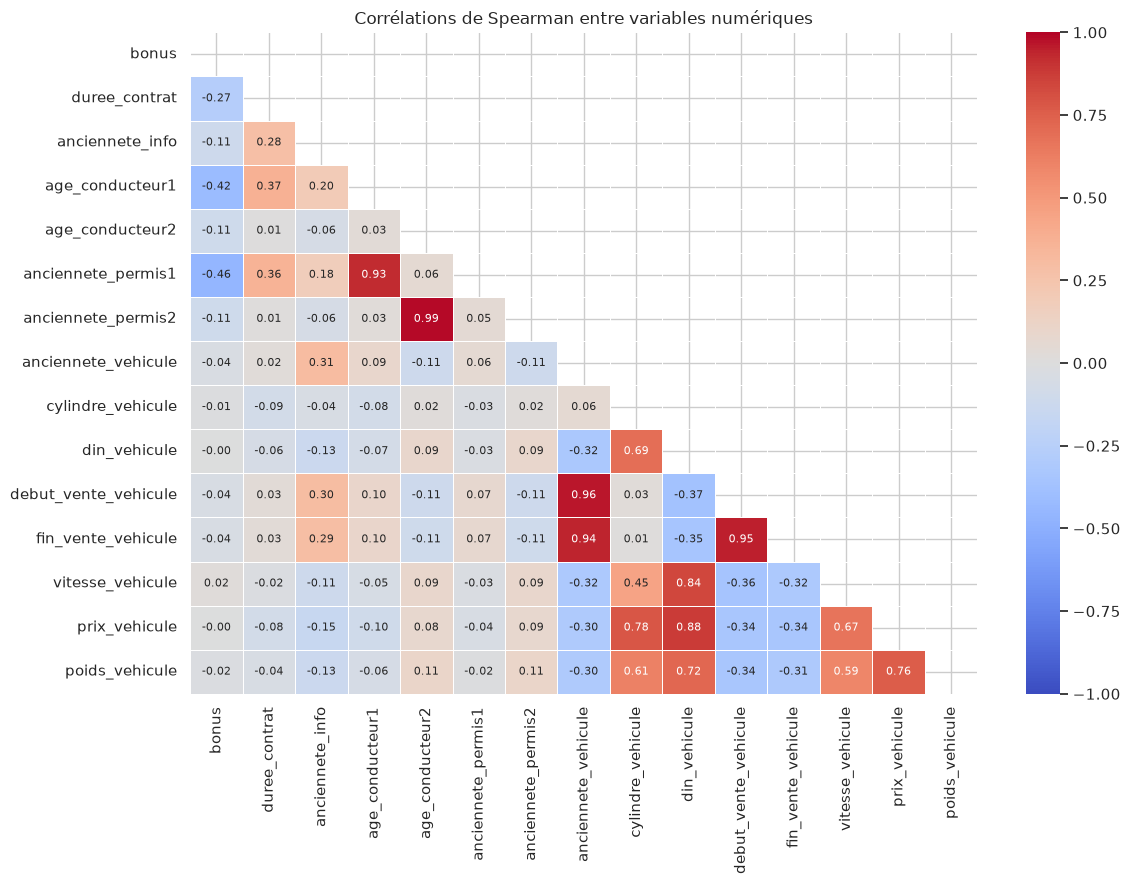

,level_0,level_1,spearman
94,anciennete_permis2,age_conducteur2,0.99
157,debut_vente_vehicule,anciennete_vehicule,0.96
175,fin_vente_vehicule,debut_vente_vehicule,0.95
172,fin_vente_vehicule,anciennete_vehicule,0.94
78,anciennete_permis1,age_conducteur1,0.93
204,prix_vehicule,din_vehicule,0.88
189,vitesse_vehicule,din_vehicule,0.84
203,prix_vehicule,cylindre_vehicule,0.78
223,poids_vehicule,prix_vehicule,0.76
219,poids_vehicule,din_vehicule,0.72


In [112]:
corr = train[numeriques].corr(method="spearman")
masque = np.triu(np.ones_like(corr, dtype=bool))  # on n'affiche que le triangle inférieur

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=masque, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Corrélations de Spearman entre variables numériques")
plt.tight_layout()
plt.show()

paires = (corr.where(~masque).stack().rename("spearman").reset_index()
          .query("abs(spearman) >= 0.7").sort_values("spearman", key=abs, ascending=False))
paires.round(2)

**Constats**
- `anciennete_vehicule`, `debut_vente_vehicule` et `fin_vente_vehicule` sont quasiment redondantes (ρ ≈ 0,95) : elles mesurent toutes « l'âge » du véhicule.
- `din_vehicule`, `prix_vehicule`, `vitesse_vehicule` (et `cylindre_vehicule`) mesurent la **puissance / gamme** du véhicule (ρ entre 0,7 et 0,9).
- L'âge du conducteur et l'ancienneté de son permis sont fortement liés, de même pour le second conducteur.

**Conséquence** :
- pour la **régression logistique**, la multicolinéarité rend les coefficients instables. On retire `debut_vente_vehicule` et `fin_vente_vehicule` et on ajoute une régularisation ;
- pour les **arbres**, ce n'est pas gênant : on garde toutes les variables.

---
# Partie 3 — Préparation des données

## 3.1 Choix des variables

| Exclues | Raison |
|---|---|
| `nombre_sinistres` | Cible |
| `montant_sinistre` | Fuite directe de la cible |
| `index`, `id_client`, `id_vehicule`, `id_contrat` | Identifiants, absents du test |
| `sex_conducteur1`, `sex_conducteur2` | **Interdits** en tarification dans l'UE depuis 2012 (arrêt Test-Achats). Leur pouvoir prédictif est de toute façon quasi nul (§2.5) |
| `code_postal` brut | Trop de modalités : remplacé par le **département** (créé dans le pipeline) |

`id_client` est conservé **à part** pour construire un découpage par client.

In [113]:
VARIABLES_EXCLUES = IDENTIFIANTS + CIBLES + ["sex_conducteur1", "sex_conducteur2"]
X_complet = train.drop(columns=VARIABLES_EXCLUES)
y_complet = train[CIBLE]
groupes = train["id_client"]
X_test_kaggle = test.drop(columns=[c for c in VARIABLES_EXCLUES if c in test.columns])

assert list(X_complet.columns) == list(X_test_kaggle.columns)
print("Variables conservées (%d) :" % X_complet.shape[1], X_complet.columns.tolist())

Variables conservées (25) : ['bonus', 'type_contrat', 'duree_contrat', 'anciennete_info', 'freq_paiement', 'paiement', 'utilisation', 'code_postal', 'conducteur2', 'age_conducteur1', 'age_conducteur2', 'anciennete_permis1', 'anciennete_permis2', 'anciennete_vehicule', 'cylindre_vehicule', 'din_vehicule', 'essence_vehicule', 'marque_vehicule', 'modele_vehicule', 'debut_vente_vehicule', 'fin_vente_vehicule', 'vitesse_vehicule', 'type_vehicule', 'prix_vehicule', 'poids_vehicule']


## 3.2 Découpage train / validation

Deux contraintes :
1. **Stratification** sur la cible : garder environ 6 % de sinistrés dans chaque jeu, sinon les résultats dépendent du hasard du tirage.
2. **Groupement par client** : environ 3 900 clients assurent plusieurs véhicules (`id_vehicule` V02 à V05). Ces lignes partagent le même conducteur et la même adresse. Si un client se retrouve à la fois en train et en validation, le modèle est évalué sur un profil qu'il a déjà vu, et la performance mesurée est **trop optimiste**.

→ On utilise `StratifiedGroupKFold` (stratifié **et** groupé) : on garde un pli sur 5 comme validation (20 %).
Le même objet servira en partie 4 pour la **validation croisée** sur le jeu d'entraînement (optimisation des hyperparamètres).

In [114]:
from sklearn.model_selection import StratifiedGroupKFold

print("Véhicules par client :", train["id_vehicule"].value_counts().to_dict())
print("Clients avec plusieurs véhicules :", (train["id_client"].value_counts() > 1).sum())

decoupage = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
idx_train, idx_valid = next(decoupage.split(X_complet, y_complet, groups=groupes))

X_train, X_valid = X_complet.iloc[idx_train], X_complet.iloc[idx_valid]
y_train, y_valid = y_complet.iloc[idx_train], y_complet.iloc[idx_valid]
groupes_train = groupes.iloc[idx_train]

print(f"\ntrain      : {len(X_train):>6} lignes | taux de sinistres = {y_train.mean():.2%}")
print(f"validation : {len(X_valid):>6} lignes | taux de sinistres = {y_valid.mean():.2%}")

clients_communs = set(groupes.iloc[idx_train]) & set(groupes.iloc[idx_valid])
print("Clients présents dans les deux jeux :", len(clients_communs))
assert len(clients_communs) == 0

# Validation croisée réutilisable en partie 4 (sur le train uniquement)
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

Véhicules par client : {'V01': 45785, 'V02': 3905, 'V03': 272, 'V04': 32, 'V05': 6}
Clients avec plusieurs véhicules : 3905

train      :  39999 lignes | taux de sinistres = 5.83%
validation :  10001 lignes | taux de sinistres = 5.84%
Clients présents dans les deux jeux : 0


## 3.3 Nettoyage

On corrige les anomalies repérées en partie 2 avec une fonction `nettoyer`, appliquée **de la même façon** au train, à la validation, aux données complètes et au test Kaggle.

| Opération | Justification |
|---|---|
| `poids_vehicule = 0` et `cylindre_vehicule = 0` → NaN | Valeurs impossibles : ce sont des valeurs manquantes déguisées, complétées à l'étape suivante |
| `code_postal` → `departement` (2 premiers chiffres) | 12 790 codes postaux → 96 départements |

Ce nettoyage ne crée **pas de fuite de données** : ce sont des règles fixes, qui n'apprennent rien sur les données.

Les zéros de `age_conducteur2` et `anciennete_permis2` (pas de second conducteur) sont **conservés** : la variable `conducteur2` permet au modèle de distinguer « pas de second conducteur » d'un vrai âge.

In [115]:
def nettoyer(df):
    df = df.copy()  # on travaille sur une copie pour ne pas modifier l'original

    # 1. Un poids ou une cylindrée de 0 est impossible : c'est une valeur manquante
    df["poids_vehicule"] = df["poids_vehicule"].replace(0, np.nan)
    df["cylindre_vehicule"] = df["cylindre_vehicule"].replace(0, np.nan)

    # 2. Code postal -> département (2 premiers chiffres)
    df["departement"] = df["code_postal"].str[:2]
    df = df.drop(columns=["code_postal"])

    return df


# On applique exactement le même nettoyage à tous les jeux de données
X_train = nettoyer(X_train)
X_valid = nettoyer(X_valid)
X_complet = nettoyer(X_complet)
X_test_kaggle = nettoyer(X_test_kaggle)

print("Valeurs manquantes après nettoyage (train) :")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

Valeurs manquantes après nettoyage (train) :
cylindre_vehicule       3
poids_vehicule       1517
dtype: int64


## 3.4 Préparation des variables pour la régression logistique

Après le nettoyage, les données ne sont pas encore utilisables par une régression logistique :
- il reste des **valeurs manquantes** (poids, cylindrée, ancienneté du véhicule) ;
- certaines variables sont du **texte** (`type_contrat`, `marque_vehicule`…) alors que le modèle n'accepte que des nombres ;
- les variables ont des **échelles très différentes** (bonus autour de 0,5, puissance autour de 90) ;
- certaines variables sont **redondantes** (voir 2.6).

### Traitements appliqués

| Étape | Variables | Traitement | Justification |
|---|---|---|---|
| Redondance | `debut_vente_vehicule`, `fin_vente_vehicule`, `anciennete_permis1`, `age_conducteur2`, `prix_vehicule`, `vitesse_vehicule` | Retirées | Doublons d'une autre variable (corrélation ≥ 0,84) : on garde dans chaque groupe la plus corrélée au sinistre |
| Valeurs manquantes | `poids_vehicule`, `cylindre_vehicule`, `anciennete_vehicule` | Médiane du **même modèle** de véhicule, sinon de la **même marque**, sinon médiane globale | Les poids manquants sont surtout des utilitaires (Trafic, Master…), plus lourds que la moyenne : la médiane globale les sous-estimerait |
| Valeurs extrêmes | `bonus`, `din_vehicule`, `poids_vehicule`, `cylindre_vehicule` | Logarithme | Limiter l'influence des valeurs extrêmes |
| Texte, peu de modalités | `type_contrat`, `utilisation`, `essence_vehicule`… | Modalités rares (< 50 lignes) regroupées dans « Autre », puis **one-hot** (une colonne 0/1 par modalité) | Transformer le texte en nombres ; la modalité la plus fréquente sert de référence et n'a pas de colonne |
| Texte, beaucoup de modalités | `marque_vehicule`, `modele_vehicule`, `departement` | Remplacées par leur **taux de sinistres lissé** | 886 modèles de véhicule → une seule colonne au lieu de 886 |
| Échelle | Toutes les variables numériques | **Standardisation** : moyenne 0, écart-type 1 | Mettre les variables à la même échelle ; les colonnes 0/1 restent telles quelles |

### Le taux de sinistres lissé
Chaque modalité est remplacée par son taux de sinistres, ramené vers le taux moyen quand elle a peu de lignes :

$$\text{valeur} = \frac{\text{nombre de sinistres} + m \times \text{taux moyen}}{\text{nombre de lignes} + m} \quad \text{avec } m = 100$$

- Département 59 (2 265 lignes) : on garde à peu près son taux observé.
- Département 2B (8 lignes, 0 sinistre) : on le ramène vers la moyenne, car 8 lignes ne prouvent rien.
- Modalité absente du train (modèles du test inconnus) : elle reçoit le taux moyen.
- **Pour le train**, le taux est calculé **« hors pli »** : on découpe le train en 5 paquets, et chaque ligne reçoit le taux calculé sur les 4 autres paquets. Sinon, le taux d'une ligne inclurait sa propre réponse (`nombre_sinistres`), et le modèle apprendrait à « tricher » sur le train. Pour la validation et le test, on utilise le taux calculé sur tout le train.

### Règle : apprendre sur le train uniquement
Le code est découpé en deux temps :
1. `apprendre(X_train, y_train)` calcule **sur le train seulement** les médianes, les taux de sinistres, les modalités fréquentes, les moyennes et les écarts-types ;
2. `preparer(X, params)` **applique** ces paramètres, sans rien recalculer, au train, à la validation et au test Kaggle.

Si ces paramètres étaient calculés en incluant la validation, de l'information sur la validation fuirait dans l'apprentissage et les performances mesurées seraient trop optimistes.

In [116]:
# --- Les groupes de colonnes ---------------------------------------------------
REDONDANTES = ["debut_vente_vehicule", "fin_vente_vehicule",   # doublons de anciennete_vehicule
               "anciennete_permis1",                            # doublon de age_conducteur1
               "age_conducteur2",                               # doublon de anciennete_permis2
               "prix_vehicule", "vitesse_vehicule"]             # doublons de din_vehicule

A_IMPUTER = ["poids_vehicule", "cylindre_vehicule", "anciennete_vehicule"]
QUEUE_LOURDE = ["bonus", "din_vehicule", "poids_vehicule", "cylindre_vehicule"]
CAT_FAIBLE = ["type_contrat", "freq_paiement", "paiement", "utilisation",
              "conducteur2", "essence_vehicule", "type_vehicule"]
CAT_FORTE = ["marque_vehicule", "modele_vehicule", "departement"]

SEUIL_RARE = 50   # une modalité avec moins de 50 lignes est regroupée dans "Autre"
LISSAGE = 100     # force du lissage du taux de sinistres


# --- Taux de sinistres « hors pli », pour le train uniquement -----------------
def taux_hors_pli(X, y, col, nb_plis=5):
    # On découpe le train en 5 paquets (plis). Chaque ligne reçoit le taux calculé
    # sur les 4 AUTRES paquets : elle ne voit donc jamais sa propre réponse.
    pli = np.random.RandomState(SEED).randint(0, nb_plis, len(X))
    taux_moyen = y.mean()
    resultat = pd.Series(np.nan, index=X.index)
    for k in range(nb_plis):
        autres = pli != k
        stats = y[autres].groupby(X.loc[autres, col]).agg(["sum", "count"])
        taux = (stats["sum"] + LISSAGE * taux_moyen) / (stats["count"] + LISSAGE)
        resultat[~autres] = X.loc[~autres, col].map(taux).fillna(taux_moyen).values
    return resultat


# --- 1. APPRENDRE les paramètres, sur le train UNIQUEMENT --------------------
def apprendre(X, y):
    p = {}

    # Imputation : médiane par modèle, sinon par marque, sinon médiane globale
    for col in A_IMPUTER:
        p[f"med_modele_{col}"] = X.groupby("modele_vehicule")[col].median()
        p[f"med_marque_{col}"] = X.groupby("marque_vehicule")[col].median()
        p[f"med_globale_{col}"] = X[col].median()

    # Modalités fréquentes (les autres seront regroupées dans "Autre")
    for col in CAT_FAIBLE:
        effectifs = X[col].value_counts()
        p[f"frequentes_{col}"] = effectifs[effectifs >= SEUIL_RARE].index
        p[f"reference_{col}"] = effectifs.index[0]  # modalité la plus fréquente = référence

    # Taux de sinistres par modalité, lissé vers le taux moyen (servira à valid / test)
    taux_moyen = y.mean()
    p["taux_moyen"] = taux_moyen
    for col in CAT_FORTE:
        stats = y.groupby(X[col]).agg(["sum", "count"])
        p[f"taux_{col}"] = (stats["sum"] + LISSAGE * taux_moyen) / (stats["count"] + LISSAGE)

    # Colonnes produites sur le train (pour que valid et test aient les mêmes)
    X_t = transformer(X, p, y)
    p["colonnes"] = X_t.columns

    # Moyennes et écarts-types pour la standardisation
    colonnes_num = [c for c in X_t.columns if X_t[c].nunique() > 2]  # on ne standardise pas les 0/1
    p["colonnes_num"] = colonnes_num
    p["moyennes"] = X_t[colonnes_num].mean()
    p["ecarts_types"] = X_t[colonnes_num].std()
    return p


# --- 2. APPLIQUER les paramètres (sans standardisation) ----------------------
def transformer(X, p, y=None):
    X = X.copy()

    # Retirer les variables redondantes
    X = X.drop(columns=REDONDANTES)

    # Imputation : modèle -> marque -> globale
    for col in A_IMPUTER:
        X[col] = X[col].fillna(X["modele_vehicule"].map(p[f"med_modele_{col}"]))
        X[col] = X[col].fillna(X["marque_vehicule"].map(p[f"med_marque_{col}"]))
        X[col] = X[col].fillna(p[f"med_globale_{col}"])

    # Log sur les variables à valeurs extrêmes
    for col in QUEUE_LOURDE:
        X[col] = np.log1p(X[col])

    # Taux de sinistres
    for col in CAT_FORTE:
        if y is not None:
            # train : taux hors pli (la ligne ne voit pas sa propre réponse)
            X[col] = taux_hors_pli(X, y, col)
        else:
            # validation / test : taux du train (modalité inconnue -> taux moyen)
            X[col] = X[col].map(p[f"taux_{col}"]).fillna(p["taux_moyen"])

    # Regrouper les modalités rares, puis one-hot
    for col in CAT_FAIBLE:
        X[col] = X[col].where(X[col].isin(p[f"frequentes_{col}"]), "Autre")
    X = pd.get_dummies(X, columns=CAT_FAIBLE, dtype=int)
    # On retire la colonne de la modalité de référence (sinon les colonnes d'une
    # même variable somment toujours à 1 : redondance parfaite)
    X = X.drop(columns=[f"{col}_{p[f'reference_{col}']}" for col in CAT_FAIBLE], errors="ignore")

    # Mêmes colonnes que le train (une modalité absente -> colonne de 0)
    if "colonnes" in p:
        X = X.reindex(columns=p["colonnes"], fill_value=0)
    return X


def preparer(X, p, y=None):
    X = transformer(X, p, y)
    X[p["colonnes_num"]] = (X[p["colonnes_num"]] - p["moyennes"]) / p["ecarts_types"]
    return X


params = apprendre(X_train, y_train)               # appris sur le train SEULEMENT

X_train_prep = preparer(X_train, params, y_train)  # train : taux hors pli
X_valid_prep = preparer(X_valid, params)           # paramètres du train réutilisés
X_test_prep = preparer(X_test_kaggle, params)

print("train :", X_train_prep.shape, "| valid :", X_valid_prep.shape, "| test :", X_test_prep.shape)
X_train_prep.head()

train : (39999, 26) | valid : (10001, 26) | test : (50000, 26)


,bonus,duree_contrat,anciennete_info,age_conducteur1,anciennete_permis2,anciennete_vehicule,cylindre_vehicule,din_vehicule,marque_vehicule,modele_vehicule,poids_vehicule,departement,type_contrat_Median1,type_contrat_Median2,type_contrat_Mini,freq_paiement_Biannual,freq_paiement_Monthly,freq_paiement_Quarterly,paiement_Yes,utilisation_Autre,utilisation_Professional,utilisation_Retired,conducteur2_Yes,essence_vehicule_Autre,essence_vehicule_Gasoline,type_vehicule_Commercial
0,-0.395533,2.083605,2.658706,2.038424,-0.536221,0.066031,0.002150,0.370793,0.529723,-1.399637,0.177141,-0.479398,0,0,0,1,0,0,0,0,0,1,0,0,1,0
1,-0.395533,-0.946827,-0.736693,0.963213,-0.536221,-0.786463,1.085361,1.928672,2.365468,1.067916,1.061027,1.321004,0,0,0,1,0,0,0,0,0,1,0,0,0,0
2,-0.395533,-1.063382,-0.312268,-1.187209,-0.536221,0.208113,0.812483,1.574126,0.909227,0.662142,0.370262,1.173228,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,-0.395533,0.568389,0.536582,0.492808,2.267195,0.208113,0.026829,0.645083,-0.337362,0.606987,0.242558,0.148042,0,0,0,1,0,0,0,0,0,1,1,0,1,0
6,-0.395533,-0.713717,0.112157,1.500819,-0.536221,-0.360216,0.588449,0.645083,-0.337362,0.606987,0.614036,0.148042,0,0,0,1,0,0,0,0,0,1,0,0,0,0


## 3.5 Vérifications

Avant de passer à la modélisation, on vérifie que la préparation a bien fonctionné :
1. les trois jeux ont le même format, sans valeur manquante ;
2. l'imputation des poids donne des valeurs cohérentes ;
3. les paramètres ont bien été appris sur le train uniquement ;
4. les modalités inconnues du test sont bien gérées ;
5. les taux de sinistres ne « trichent » pas sur le train.

### 1. Même format, sans valeur manquante

In [117]:
print("Mêmes colonnes train / valid :", list(X_train_prep.columns) == list(X_valid_prep.columns))
print("Mêmes colonnes train / test  :", list(X_train_prep.columns) == list(X_test_prep.columns))
print("Valeurs manquantes (train, valid, test) :",
      X_train_prep.isna().sum().sum(), X_valid_prep.isna().sum().sum(), X_test_prep.isna().sum().sum())
print("Colonnes non numériques :", X_train_prep.select_dtypes(exclude="number").columns.tolist())

Mêmes colonnes train / valid : True
Mêmes colonnes train / test  : True
Valeurs manquantes (train, valid, test) : 0 0 0
Colonnes non numériques : []


### 2. Imputation des poids manquants
On regarde le poids attribué aux véhicules dont le poids était manquant, pour les modèles les plus concernés.

In [118]:
manquants = X_train.loc[X_train["poids_vehicule"].isna(), ["modele_vehicule"]].copy()
# on reprend les données avant standardisation, et on annule le log pour retrouver des kg
manquants["poids imputé (kg)"] = np.expm1(
    transformer(X_train, params, y_train).loc[manquants.index, "poids_vehicule"]).round()

display(manquants.groupby("modele_vehicule")["poids imputé (kg)"]
        .agg(["count", "median"]).sort_values("count", ascending=False).head(5))
print("Poids médian global du train :", X_train["poids_vehicule"].median(), "kg")

,count,median
modele_vehicule,,
TRAFIC,240,1845.0
MASTER,142,1887.0
TRANSIT,114,1670.0
BOXER,94,1885.0
VITO,77,2600.0


Poids médian global du train : 1145.0 kg


### 3. Paramètres appris sur le train uniquement
Les variables numériques doivent avoir une moyenne de 0 et un écart-type de 1 **sur le train**. Sur la validation, elles doivent en être **proches sans être exactement égales** : cela prouve que la validation a été transformée avec les paramètres du train, sans les recalculer.

In [119]:
print("Taux moyen retenu :", round(params["taux_moyen"], 4), "| taux du train :", round(y_train.mean(), 4))

comparaison = pd.DataFrame({
    "moyenne train": X_train_prep[params["colonnes_num"]].mean(),
    "écart-type train": X_train_prep[params["colonnes_num"]].std(),
    "moyenne validation": X_valid_prep[params["colonnes_num"]].mean(),
    "écart-type validation": X_valid_prep[params["colonnes_num"]].std(),
}).round(3)
comparaison

Taux moyen retenu : 0.0583 | taux du train : 0.0583


,moyenne train,écart-type train,moyenne validation,écart-type validation
bonus,-0.0,1.0,0.000,1.006
duree_contrat,-0.0,1.0,-0.019,0.993
anciennete_info,-0.0,1.0,-0.019,0.984
age_conducteur1,0.0,1.0,-0.006,0.995
anciennete_permis2,-0.0,1.0,-0.012,0.982
anciennete_vehicule,-0.0,1.0,-0.003,0.981
cylindre_vehicule,0.0,1.0,0.002,0.981
din_vehicule,-0.0,1.0,0.008,1.000
marque_vehicule,-0.0,1.0,0.014,0.972
modele_vehicule,0.0,1.0,-0.014,1.050


### 4. Modalités inconnues du test
Certains modèles de véhicule du test n'existent pas dans le train : ils doivent recevoir le taux moyen.

In [120]:
inconnus = ~X_test_kaggle["modele_vehicule"].isin(params["taux_modele_vehicule"].index)
print("Lignes du test avec un modèle inconnu du train :", inconnus.sum())
print("Valeur reçue (avant standardisation) :",
      transformer(X_test_kaggle, params).loc[inconnus, "modele_vehicule"].unique().round(4))

Lignes du test avec un modèle inconnu du train : 258
Valeur reçue (avant standardisation) : [0.0583]


### 5. Les taux de sinistres ne trichent pas
Si le taux d'une ligne incluait sa propre réponse, la colonne serait beaucoup plus corrélée au sinistre sur le train que sur la validation.

In [121]:
pd.DataFrame({
    "corrélation train": X_train_prep[CAT_FORTE].corrwith(y_train),
    "corrélation validation": X_valid_prep[CAT_FORTE].corrwith(y_valid),
}).round(3)

,corrélation train,corrélation validation
marque_vehicule,0.019,0.016
modele_vehicule,0.061,0.059
departement,0.023,0.029


### Bilan des vérifications
- Les trois jeux ont **les mêmes 26 colonnes**, toutes numériques, **sans aucune valeur manquante**.
- Les poids imputés sont **cohérents** : environ 1 850 kg pour un Trafic ou un Master, contre une médiane globale de 1 145 kg. Une imputation par la médiane globale aurait fortement sous-estimé le poids de ces utilitaires.
- Les variables numériques ont une moyenne de 0 et un écart-type de 1 sur le train, et des valeurs **proches mais pas identiques** sur la validation : les paramètres ont bien été appris **sur le train uniquement**.
- Les lignes du test avec un modèle de véhicule inconnu reçoivent le **taux moyen** (5,8 %).
- Grâce au calcul hors pli, les taux de sinistres ont **la même corrélation sur le train et sur la validation** (environ 0,06 pour le modèle de véhicule) : ils n'apportent pas de fausse information au modèle.

## 3.6 Conclusion de la préparation : données disponibles pour la partie 4

### Les tableaux prêts pour le modèle

| Objet | Lignes | Contenu |
|---|---|---|
| `X_train_prep`, `y_train` | 39 999 (80 %) | Variables préparées et cible, pour **entraîner** le modèle |
| `X_valid_prep`, `y_valid` | 10 001 (20 %) | Variables préparées et cible, pour **évaluer** le modèle sur des clients jamais vus |
| `X_test_prep` | 50 000 | Variables préparées du test Kaggle, pour **prédire** et soumettre |

Les trois tableaux ont **les mêmes 26 colonnes**, uniquement numériques et sans valeur manquante :
- **12 colonnes numériques standardisées**, dont les 3 taux de sinistres (`marque_vehicule`, `modele_vehicule`, `departement`) ;
- **14 colonnes 0/1** issues du one-hot (par exemple `type_contrat_Mini`, `freq_paiement_Monthly`), chacune à lire par rapport à la modalité de référence de sa variable.

### Les autres objets utiles

| Objet | Utilité |
|---|---|
| `params` | Tout ce qui a été appris sur le train (médianes, taux, moyennes, écarts-types) |
| `apprendre`, `preparer` | Les fonctions de préparation, à réutiliser telles quelles |
| `X_complet`, `y_complet` | Toutes les données d'entraînement (déjà nettoyées), pour le **réentraînement final** avant la soumission Kaggle |
| `test["index"]` | Identifiant de chaque ligne du test, pour le fichier de soumission |

### Pour la soumission finale (partie 6)
On réapprendra les paramètres sur **toutes** les données d'entraînement, puis on préparera le test avec ces nouveaux paramètres :
```python
params_final = apprendre(X_complet, y_complet)
X_complet_prep = preparer(X_complet, params_final, y_complet)
X_test_prep_final = preparer(X_test_kaggle, params_final)
```

---
# Partie 4 — Modélisation de la fréquence

Objectif : prédire pour chaque client la **probabilité d'avoir au moins un sinistre**.

Démarche :
1. choisir une **métrique** adaptée ;
2. établir des **références** simples (taux moyen, puis régression logistique) ;
3. entraîner un **modèle plus complexe** et **optimiser les hyperparamètres** ;
4. **comparer** train et validation, puis conclure (sous- ou sur-apprentissage, gain par rapport à la référence).

## 4.1 Choix de la métrique

### Les classes sont déséquilibrées : l'accuracy est trompeuse
Il y a environ 94 % de non-sinistrés pour 6 % de sinistrés. Un modèle qui prédit « aucun sinistre » pour tout le monde obtient environ **94 % de bonnes réponses** (accuracy) sans rien avoir appris. L'accuracy ne permet donc pas de distinguer un bon modèle d'un modèle inutile.

### La probabilité doit être juste, pas seulement bien ordonnée
La probabilité prédite sera **multipliée par un montant** pour calculer la prime. Si le modèle annonce 12 % au lieu de 6 %, la prime est deux fois trop chère. Il faut donc une métrique qui vérifie que la probabilité est juste **en valeur** (on dit qu'elle est **bien calibrée**).

### Métriques retenues

| Métrique | Ce qu'elle mesure | Lecture |
|---|---|---|
| **Log-loss** (métrique principale) | L'erreur entre la probabilité prédite et ce qui s'est passé : $-\ln(\text{probabilité donnée à ce qui s'est réellement passé})$, en moyenne sur les clients. Elle pénalise fortement un modèle sûr de lui qui se trompe | Plus c'est **bas**, mieux c'est |
| **Score de Brier** | L'erreur quadratique moyenne entre la probabilité prédite et la réalité (0 ou 1) | Plus c'est **bas**, mieux c'est |
| **AUC / Gini** | La capacité à **classer** les clients du moins au plus risqué. L'AUC est la probabilité qu'un sinistré tiré au hasard ait un score plus élevé qu'un non-sinistré tiré au hasard. Gini $= 2 \times AUC - 1$ | 0 = hasard, 1 = classement parfait |

La log-loss et le Brier vérifient la **calibration**, indispensable pour la prime. L'AUC/Gini vérifie seulement le **classement** : un modèle qui doublerait toutes les probabilités aurait le même Gini, mais une très mauvaise log-loss. On choisit donc les modèles avec la **log-loss**, et le Gini sert de complément.

> À vérifier : la métrique utilisée pour le classement sur la page Kaggle de la compétition.

In [122]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score


def evaluer(y, proba):
    # Les trois métriques retenues pour une probabilité prédite
    auc = roc_auc_score(y, proba)
    return {"log-loss": log_loss(y, proba),
            "Brier": brier_score_loss(y, proba),
            "Gini": 2 * auc - 1}

## 4.2 Références (baselines)

Le score d'un modèle n'a de sens que comparé à une référence. On en établit deux :
1. **Le taux moyen** : prédire 5,8 % (taux de sinistres du train) pour tout le monde, sans regarder aucune variable. C'est le modèle le plus simple possible : un modèle utile doit faire mieux.
2. **La régression logistique** avec ses réglages par défaut : le modèle linéaire de référence pour une probabilité.

### Référence 1 : le taux moyen

In [123]:
taux_moyen_train = y_train.mean()
proba_ref_train = np.full(len(y_train), taux_moyen_train)
proba_ref_valid = np.full(len(y_valid), taux_moyen_train)

# Illustration du piège de l'accuracy : prédire « aucun sinistre » pour tout le monde
accuracy_ref = (y_valid == 0).mean()
print(f"Accuracy du modèle « aucun sinistre » : {accuracy_ref:.1%}  <- élevée, mais le modèle n'a rien appris")

resultats = {}  # on y range les scores de chaque modèle, sur le train et la validation
resultats["Taux moyen"] = {"train": evaluer(y_train, proba_ref_train),
                           "validation": evaluer(y_valid, proba_ref_valid)}
pd.DataFrame(resultats["Taux moyen"]).T.round(4)

Accuracy du modèle « aucun sinistre » : 94.2%  <- élevée, mais le modèle n'a rien appris


,log-loss,Brier,Gini
train,0.2223,0.0549,0.0
validation,0.2225,0.0550,0.0


→ Le taux moyen a un Gini de 0 : il ne classe personne. Sa log-loss (≈ 0,222) est **le score à battre**.

### Référence 2 : la régression logistique (réglages par défaut)

La régression logistique calcule, pour chaque client, un **score** = somme pondérée de ses 26 variables, puis transforme ce score en probabilité entre 0 et 1. Pendant l'entraînement, elle cherche les poids (**coefficients**) qui rendent les probabilités prédites les plus proches des sinistres observés sur le train.

In [124]:
reg_log_defaut = LogisticRegression(max_iter=2000)
reg_log_defaut.fit(X_train_prep, y_train)

resultats["Régression logistique (défaut)"] = {
    "train": evaluer(y_train, reg_log_defaut.predict_proba(X_train_prep)[:, 1]),
    "validation": evaluer(y_valid, reg_log_defaut.predict_proba(X_valid_prep)[:, 1]),
}
pd.DataFrame(resultats["Régression logistique (défaut)"]).T.round(4)

,log-loss,Brier,Gini
train,0.2135,0.0540,0.3115
validation,0.2137,0.0542,0.3133


→ La régression logistique fait **mieux que le taux moyen** en validation (log-loss plus basse, Gini nettement positif) : les variables apportent une vraie information. Les scores train et validation sont proches : pas de sur-apprentissage.

## 4.3 Optimisation des hyperparamètres et modèle plus complexe

### Pourquoi une validation croisée ?
Un **hyperparamètre** est un réglage du modèle qu'on choisit avant l'entraînement (par exemple la force de la régularisation). Pour le choisir, on compare plusieurs valeurs.

On ne peut pas les comparer sur le jeu de validation : à force de choisir ce qui marche le mieux sur la validation, on finirait par « apprendre » la validation, et son score ne serait plus une estimation honnête. On garde donc la validation pour la **fin**, et on compare les réglages par **validation croisée sur le train** :
- on découpe le train en 5 paquets (plis), **par client** et en gardant 6 % de sinistrés dans chacun (`cv`, défini en 3.2) ;
- 5 fois de suite, on entraîne sur 4 paquets et on évalue sur le 5ᵉ ;
- on fait la moyenne des 5 scores.

**Point important** : dans chaque pli, la préparation (`apprendre`) est refaite sur les 4 paquets d'entraînement seulement. Sinon, les médianes, taux et moyennes contiendraient de l'information sur le paquet d'évaluation.

On prépare les 5 plis une seule fois, puis on les réutilise pour tous les modèles testés.

In [125]:
plis = []
for positions_entr, positions_eval in cv.split(X_train, y_train, groups=groupes_train):
    X_entr, X_eval = X_train.iloc[positions_entr], X_train.iloc[positions_eval]
    y_entr, y_eval = y_train.iloc[positions_entr], y_train.iloc[positions_eval]

    params_pli = apprendre(X_entr, y_entr)  # préparation apprise sur les 4 paquets seulement
    plis.append((preparer(X_entr, params_pli, y_entr), y_entr,
                 preparer(X_eval, params_pli), y_eval))

print("Nombre de plis :", len(plis))
for i, (_, y_entr, _, y_eval) in enumerate(plis, 1):
    print(f"pli {i} : {len(y_entr)} lignes d'entraînement, {len(y_eval)} d'évaluation, "
          f"taux de sinistres en évaluation = {y_eval.mean():.2%}")


def log_loss_cv(creer_modele):
    # Log-loss moyenne sur les 5 plis pour un modèle donné
    scores = []
    for X_entr, y_entr, X_eval, y_eval in plis:
        modele = creer_modele()
        modele.fit(X_entr, y_entr)
        scores.append(log_loss(y_eval, modele.predict_proba(X_eval)[:, 1]))
    return np.mean(scores), np.std(scores)

Nombre de plis : 5
pli 1 : 31999 lignes d'entraînement, 8000 d'évaluation, taux de sinistres en évaluation = 5.84%
pli 2 : 31998 lignes d'entraînement, 8001 d'évaluation, taux de sinistres en évaluation = 5.84%
pli 3 : 32000 lignes d'entraînement, 7999 d'évaluation, taux de sinistres en évaluation = 5.83%
pli 4 : 31999 lignes d'entraînement, 8000 d'évaluation, taux de sinistres en évaluation = 5.84%
pli 5 : 32000 lignes d'entraînement, 7999 d'évaluation, taux de sinistres en évaluation = 5.83%


### Optimisation de la régression logistique : la régularisation `C`

La **régularisation** empêche les coefficients de devenir trop grands, ce qui limite le sur-apprentissage.
- `C` petit : régularisation **forte**, coefficients écrasés vers 0, modèle très prudent (risque de sous-apprentissage) ;
- `C` grand : régularisation **faible**, le modèle colle davantage aux données du train (risque de sur-apprentissage).

Par défaut, `C = 1`.

In [126]:
lignes = []
for C in [0.001, 0.01, 0.1, 1, 10]:
    moyenne, ecart = log_loss_cv(lambda: LogisticRegression(C=C, max_iter=2000))
    lignes.append({"C": C, "log-loss CV (moyenne)": moyenne, "écart-type entre plis": ecart})

recherche_reg_log = pd.DataFrame(lignes).set_index("C")
meilleur_C = recherche_reg_log["log-loss CV (moyenne)"].idxmin()
print("Meilleur C :", meilleur_C)
recherche_reg_log.round(5)

Meilleur C : 0.1


,log-loss CV (moyenne),écart-type entre plis
C,,
0.001,0.21564,0.00065
0.010,0.21437,0.00092
0.100,0.21420,0.00098
1.000,0.21422,0.00100
10.000,0.21422,0.00100


### Un modèle plus complexe : le gradient boosting

La régression logistique ne capte que des effets **linéaires** et additifs. Le **gradient boosting** (`HistGradientBoostingClassifier`) est un modèle plus complexe :
- il construit une **suite de petits arbres de décision** (des successions de questions du type « le véhicule a-t-il moins de 5 ans ? ») ;
- chaque nouvel arbre corrige les erreurs des arbres précédents ;
- il peut capter des effets **non linéaires** et des **interactions** entre variables.

Ses principaux hyperparamètres :

| Hyperparamètre | Rôle | Plus grand = |
|---|---|---|
| `max_iter` | Nombre d'arbres | Modèle plus complexe |
| `max_leaf_nodes` | Taille de chaque arbre (nombre de feuilles) | Modèle plus complexe |
| `learning_rate` | Poids de chaque nouvel arbre dans la correction | Apprentissage plus rapide, plus risqué |
| `min_samples_leaf` | Nombre minimum de clients par feuille | Modèle plus **prudent** |

On teste quelques combinaisons prudentes (avec seulement 6 % de sinistrés, le signal est faible), plus un réglage **volontairement complexe** (`learning_rate` = 0,1, 31 feuilles, 300 arbres) pour observer l'effet de la complexité.

In [ ]:
# (learning_rate, max_leaf_nodes, max_iter) : 8 réglages prudents + 1 réglage complexe
reglages = [(lr, feuilles, arbres) for lr in [0.03, 0.05] for feuilles in [3, 7] for arbres in [100, 200]]
reglages.append((0.1, 31, 300))

lignes = []
for learning_rate, max_leaf_nodes, max_iter in reglages:
    moyenne, ecart = log_loss_cv(lambda: HistGradientBoostingClassifier(
        learning_rate=learning_rate, max_leaf_nodes=max_leaf_nodes, max_iter=max_iter,
        min_samples_leaf=300, l2_regularization=1.0, early_stopping=False, random_state=SEED))
    lignes.append({"learning_rate": learning_rate, "max_leaf_nodes": max_leaf_nodes,
                   "max_iter": max_iter, "log-loss CV (moyenne)": moyenne,
                   "écart-type entre plis": ecart})

recherche_boosting = pd.DataFrame(lignes).sort_values("log-loss CV (moyenne)")
meilleurs_reglages = recherche_boosting.iloc[0]
print("Meilleurs réglages :", meilleurs_reglages[["learning_rate", "max_leaf_nodes", "max_iter"]].to_dict())
recherche_boosting.round(5)

→ Constats :
- Le réglage **volontairement complexe** obtient la **moins bonne** log-loss : le modèle apprend les particularités du train au lieu de règles générales, c'est du **sur-apprentissage**.
- Même avec ses meilleurs réglages, le gradient boosting fait **légèrement moins bien** que la régression logistique en validation croisée (≈ 0,2148 contre 0,2142). L'écart est toutefois plus petit que la variabilité entre plis (écart-type ≈ 0,001).

## 4.4 Comparaison train / validation et conclusion

On réentraîne les modèles retenus sur **tout le train** avec leurs meilleurs réglages, puis on les évalue **une seule fois** sur la validation.

In [ ]:
reg_log = LogisticRegression(C=meilleur_C, max_iter=2000)
reg_log.fit(X_train_prep, y_train)

boosting = HistGradientBoostingClassifier(
    learning_rate=meilleurs_reglages["learning_rate"],
    max_leaf_nodes=int(meilleurs_reglages["max_leaf_nodes"]),
    max_iter=int(meilleurs_reglages["max_iter"]),
    min_samples_leaf=300, l2_regularization=1.0, early_stopping=False, random_state=SEED)
boosting.fit(X_train_prep, y_train)

for nom, modele in [(f"Régression logistique (C = {meilleur_C})", reg_log), ("Gradient boosting", boosting)]:
    resultats[nom] = {"train": evaluer(y_train, modele.predict_proba(X_train_prep)[:, 1]),
                      "validation": evaluer(y_valid, modele.predict_proba(X_valid_prep)[:, 1])}

# Tableau récapitulatif : une ligne par modèle, train et validation côte à côte
tableau = pd.concat({nom: pd.DataFrame(scores).T.stack() for nom, scores in resultats.items()}, axis=1).T
tableau.columns = [f"{metrique} ({jeu})" for jeu, metrique in tableau.columns]
colonnes = [f"{m} ({j})" for m in ["log-loss", "Brier", "Gini"] for j in ["train", "validation"]]
tableau = tableau[colonnes]

ref = tableau.loc["Taux moyen", "log-loss (validation)"]
tableau["gain de log-loss vs taux moyen (validation)"] = (1 - tableau["log-loss (validation)"] / ref)
tableau.round(4)

,log-loss (train),log-loss (validation),Brier (train),Brier (validation),Gini (train),Gini (validation),gain de log-loss vs taux moyen (validation)
Taux moyen,0.2223,0.2225,0.0549,0.0550,0.0000,0.0000,0.0000
Régression logistique (défaut),0.2135,0.2137,0.0540,0.0542,0.3115,0.3133,0.0395
Régression logistique (C = 0.1),0.2135,0.2137,0.0540,0.0542,0.3110,0.3135,0.0394
Gradient boosting,0.2123,0.2135,0.0538,0.0541,0.3366,0.3174,0.0407


### Calibration : les probabilités prédites sont-elles justes ?

On range les clients de la validation en 10 groupes, du moins au plus risqué selon le modèle, et on compare dans chaque groupe :
- la **probabilité moyenne prédite** ;
- le **taux de sinistres réellement observé**.

Si le modèle est bien calibré, les points sont proches de la diagonale.

Régression logistique  : sinistres prédits = 583 | sinistres observés = 584
Gradient boosting      : sinistres prédits = 584 | sinistres observés = 584


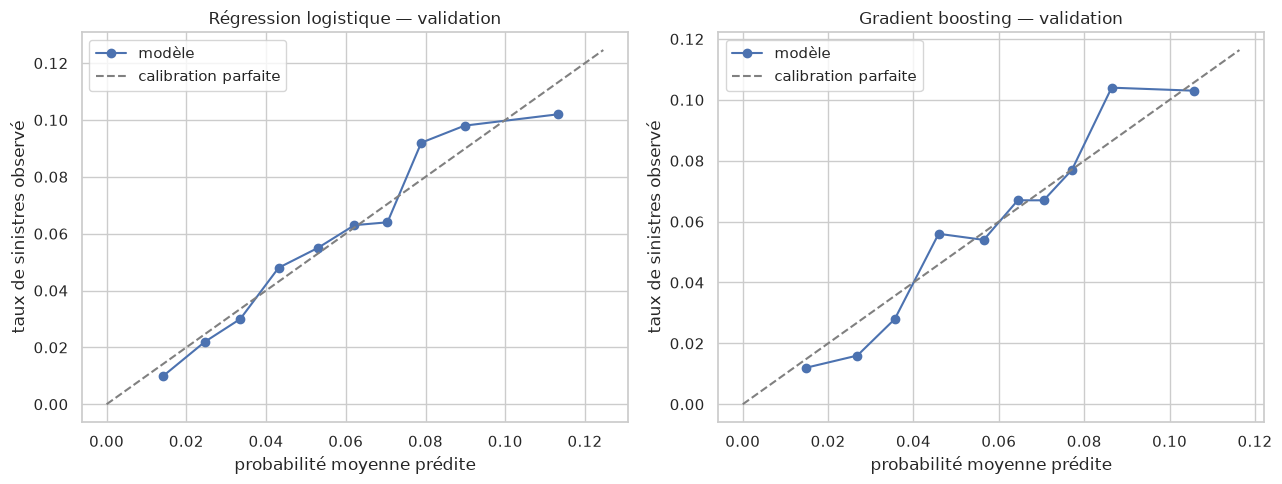

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (nom, modele) in zip(axes, [("Régression logistique", reg_log), ("Gradient boosting", boosting)]):
    proba = modele.predict_proba(X_valid_prep)[:, 1]
    groupes_risque = pd.qcut(proba, 10, labels=False, duplicates="drop")
    calibration = pd.DataFrame({"prédit": proba, "observé": y_valid.values}).groupby(groupes_risque).mean()

    ax.plot(calibration["prédit"], calibration["observé"], "o-", label="modèle")
    limite = calibration.max().max() * 1.1
    ax.plot([0, limite], [0, limite], "--", color="grey", label="calibration parfaite")
    ax.set_title(f"{nom} — validation")
    ax.set_xlabel("probabilité moyenne prédite")
    ax.set_ylabel("taux de sinistres observé")
    ax.legend()

    print(f"{nom:22s} : sinistres prédits = {proba.sum():.0f} | sinistres observés = {y_valid.sum()}")

plt.tight_layout()
plt.show()

### Interprétation de la régression logistique

Les variables étant standardisées (ou 0/1), on peut comparer les coefficients entre eux :
- un coefficient **positif** augmente le risque, un coefficient **négatif** le diminue ;
- pour une colonne 0/1, l'effet se lit **par rapport à la modalité de référence** (par exemple `type_contrat_Mini` par rapport à `Maxi`).

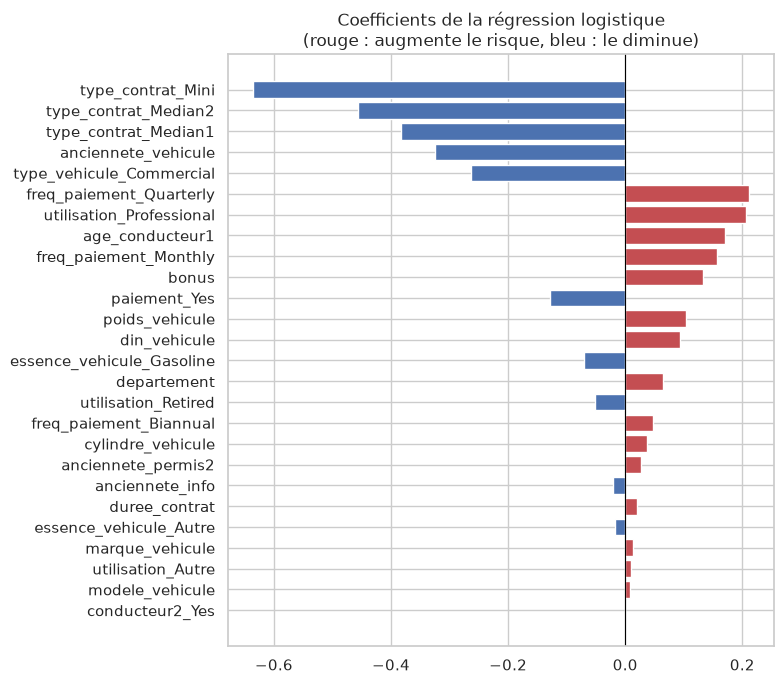

,coefficient
type_contrat_Mini,-0.636
type_contrat_Median2,-0.456
type_contrat_Median1,-0.384
anciennete_vehicule,-0.325
type_vehicule_Commercial,-0.263
freq_paiement_Quarterly,0.212
utilisation_Professional,0.207
age_conducteur1,0.170
freq_paiement_Monthly,0.157
bonus,0.132


In [ ]:
coefficients = pd.Series(reg_log.coef_[0], index=X_train_prep.columns, name="coefficient")
coefficients = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 7))
couleurs = ["#C44E52" if c > 0 else "#4C72B0" for c in coefficients]
plt.barh(coefficients.index[::-1], coefficients.values[::-1], color=couleurs[::-1])
plt.axvline(0, color="black", lw=0.8)
plt.title("Coefficients de la régression logistique\n(rouge : augmente le risque, bleu : le diminue)")
plt.tight_layout()
plt.show()

coefficients.round(3).to_frame().head(10)

### Conclusion de la partie 4

**Gain par rapport à la référence**
- La régression logistique fait nettement mieux que le taux moyen : log-loss de validation **0,2137 contre 0,2225** (environ −4 %), et un **Gini d'environ 0,31** contre 0 pour la référence.
- Le gain reste modeste en valeur absolue : la survenue d'un sinistre automobile est en grande partie **aléatoire**, et les variables disponibles n'en expliquent qu'une partie. C'est normal en tarification.

**Sous-apprentissage ou sur-apprentissage ?**
- **Régression logistique** : les scores sont quasiment identiques sur le train et la validation (log-loss 0,2135 / 0,2137, Gini 0,311 / 0,313) : **pas de sur-apprentissage**. La régularisation change très peu de chose (`C` = 1 et `C` = 0,1 donnent le même résultat), car il y a 40 000 lignes pour seulement 26 variables. Le modèle étant linéaire, il peut en revanche manquer des effets non linéaires : c'est un **léger sous-apprentissage possible**, d'où l'essai d'un modèle plus complexe.
- **Gradient boosting** : il fait mieux sur le train que sur la validation (Gini 0,337 contre 0,317) : **léger sur-apprentissage**, qui devient fort quand on augmente sa complexité. Une fois réglé prudemment, il est **équivalent** à la régression logistique : un peu moins bon en validation croisée (0,2148 contre 0,2142), un peu meilleur sur la validation (0,2135 contre 0,2137). Ces écarts sont plus petits que la variabilité entre plis, ils ne sont donc pas significatifs.

**Calibration**
- Les deux modèles sont **bien calibrés** : les points suivent la diagonale, et le nombre total de sinistres prédits sur la validation (≈ 583) est quasiment égal au nombre observé (584). La régression logistique surestime légèrement le risque des clients les plus risqués.

**Modèle retenu : la régression logistique (C = 0,1)**
- Performance équivalente au gradient boosting ;
- plus **simple**, plus **stable** (pas d'écart entre train et validation) ;
- **interprétable** : ses coefficients sont cohérents avec l'analyse exploratoire. Le type de contrat (Mini, Median moins risqués que Maxi), l'ancienneté du véhicule (véhicules récents plus risqués) et le type de véhicule (utilitaires moins risqués) sont les effets les plus forts.

**Piste d'amélioration** : la préparation des données a été conçue pour la régression logistique (one-hot, standardisation, variables redondantes retirées). Le gradient boosting pourrait mieux faire avec une préparation adaptée aux arbres (variables brutes conservées, sans log ni standardisation).